### 📊 Mục tiêu của notebook này

Notebook minh họa **toàn bộ lý thuyết Phần 1** từ dữ liệu giả lập có kiểm soát, bao gồm:

1. **OLS Core** — Ước lượng β̂, σ², các chỉ số mô hình (RSS, R², F-stat)
2. **Hat Matrix & Suy diễn thống kê** — SE, t-test, p-value, VIF
3. **Ridge & Lasso** — Regularization, Ridge Trace, Lasso Path
4. **Phân tích phần dư** — 4 biểu đồ chẩn đoán, Cook's Distance
5. **Cross-Validation** — k-fold CV, chọn λ tối ưu
6. **Kiểm chứng với sklearn** — Đảm bảo tính đúng đắn của code
7. **⭐ Gauss-Markov Monte Carlo** — Mô phỏng 2000 mẫu kiểm chứng E[β̂]=β và OLS có phương sai nhỏ nhất

---

> **Tại sao dùng dữ liệu giả lập (synthetic data)?**  

In [2]:
# Import các module tự cài đặt
from ols_implementation import (
    ols_fit, OLSRegressor, hat_matrix, coef_inference, vif,
    model_metrics, verify_with_sklearn,
)
from ridge_lasso import (
    ridge_fit, lasso_fit,
    RidgeRegressor, LassoRegressor,
    verify_ridge_sklearn, verify_lasso_sklearn
)
from residual_analysis import residual_plots, compute_leverage_and_cooks
from cross_validation import kfold_cv

# Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec
from scipy.stats import truncnorm


# Seed toàn cục để tái lập kết quả
SEED = 42
np.random.seed(SEED)

print("☑️ Import thành công. Seed:", SEED)

☑️ Import thành công. Seed: 42


---
## Phần 0: Thiết kế Dữ liệu Giả lập — Thị trường Bất động sản

### Kịch bản

Ta mô phỏng **thị trường nhà ở** tương tự dataset Ames Housing (Iowa, Mỹ).  
Giá nhà được mô hình hóa theo **log-log regression**:

$$\ln(\text{SalePrice}) = \beta_0 + \beta_1 \ln(\text{GrLivArea}) + \beta_2 \ln(\text{BsmtSF}) + \beta_3 \ln(\text{GarageArea}) + \beta_4 \cdot \text{OverallQual} + \beta_5 \cdot \text{YearNorm} + \varepsilon$$

Trong đó $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.

### Tại sao log-log?

- **SalePrice** và diện tích có phân phối lệch phải mạnh → log-transform tạo phân phối gần chuẩn hơn
- Hệ số $\beta_j$ trong log-log có ý nghĩa là **hệ số co giãn**: tăng 1% diện tích → giá tăng $\beta_j$%
- Đây là mô hình chuẩn trong kinh tế học bất động sản (hedonic pricing model)

### Phân phối của từng biến (ước lượng từ dữ liệu Ames thật)

| Biến | Phân phối | Tham số (từ data thật) | Ý nghĩa |
|------|-----------|------------------------|---------|
| `GrLivArea` | Log-Normal | μ=7.26, σ=0.32 | Diện tích sàn (sq ft) |
| `TotalBsmtSF` | Log-Normal | μ=6.73, σ=1.18 | Diện tích tầng hầm |
| `GarageArea` | Log-Normal | μ=5.81, σ=1.43 | Diện tích garage |
| `OverallQual` | Truncated Normal | μ=6.1, σ=1.41, [1,10] | Chất lượng tổng thể |
| `YearBuilt` | Truncated Normal | μ=1971, σ=30 | Năm xây dựng |
| `ε` (nhiễu) | Normal | σ=0.173 | Các yếu tố không quan sát được |

### β_true (ước lượng từ OLS trên Ames Housing thật)

```python
beta_true = {
    'intercept': 7.463,
    'log_area' : 0.478,   # tăng 1% diện tích → giá tăng 0.48%
    'log_bsmt' : 0.035,
    'log_garage': 0.028,
    'qual'      : 0.114,   # tăng 1 bậc chất lượng → giá tăng 11.4%
    'year_norm' : 0.090    # nhà mới hơn 1σ (~30 năm) → giá tăng 9%
}

In [3]:
# ============================================================
# PHẦN 0: SINH DỮ LIỆU GIẢ LẬP — THỊ TRƯỜNG BẤT ĐỘNG SẢN
# Tất cả tham số được ước lượng từ Ames Housing dataset thật
# ============================================================


# --- Tham số ước lượng từ data thật ---
BETA_TRUE = np.array([7.4632, 0.4777, 0.0347, 0.0276, 0.1140, 0.0900])
# [intercept, log_area, log_bsmt, log_garage, qual, year_norm]
SIGMA_TRUE = 0.173   # std phần dư thực tế của mô hình log-log

FEATURE_NAMES = ['intercept', 'log_GrLivArea', 'log_BsmtSF', 'log_GarageArea', 
                 'OverallQual', 'YearNorm']


def generate_housing_data(n: int, seed: int = 42) -> dict:
    """
    Sinh n căn nhà giả lập theo phân phối ước lượng từ Ames Housing.
    
    Mỗi biến được sinh từ phân phối phù hợp với bản chất kinh tế của nó:
    - Diện tích: Log-Normal (lệch phải, không âm)
    - Chất lượng: Truncated Normal làm tròn sang integer [1,10]  
    - Năm xây: Normal rồi chuẩn hóa
    - Nhiễu: Gaussian (các yếu tố không quan sát được)
    
    Returns: dict với X (n,5), y_log (n,), y_price (n,), X_raw (n,5)
    """
    rng = np.random.default_rng(seed)
    
    # 1. Diện tích sàn: Log-Normal (mu, sigma của log)
    log_area = rng.normal(loc=7.2602, scale=0.3246, size=n)
    area = np.exp(log_area)  # GrLivArea thực (sq ft)
    
    # 2. Diện tích tầng hầm: Log-Normal, có thể = 0 (nhà không có hầm)
    #    Mô phỏng: 15% nhà không có tầng hầm → log(1) = 0
    has_bsmt = rng.random(n) > 0.15
    log_bsmt = np.where(
        has_bsmt,
        rng.normal(loc=6.73, scale=0.65, size=n),  # có tầng hầm
        0.0   # log(1) = 0, nghĩa là bsmt = 1 sq ft (xử lý log(0))
    )
    log_bsmt = np.clip(log_bsmt, 0, None)  # không âm
    bsmt_sf = np.exp(log_bsmt)
    
    # 3. Garage Area: Log-Normal, 8% không có garage
    has_garage = rng.random(n) > 0.08
    log_garage = np.where(
        has_garage,
        rng.normal(loc=6.10, scale=0.55, size=n),
        0.0
    )
    log_garage = np.clip(log_garage, 0, None)
    garage_area = np.exp(log_garage)
    
    # 4. Overall Quality: Truncated Normal [1,10], làm tròn sang integer
    #    Dùng clip thay vì truncnorm cho đơn giản
    qual_raw = rng.normal(loc=6.096, scale=1.41, size=n)
    qual = np.clip(np.round(qual_raw), 1, 10).astype(int)
    
    # 5. Year Built → chuẩn hóa: (year - 1971) / 30
    YEAR_MU, YEAR_SIGMA = 1971, 30
    YEAR_LO,  YEAR_HI  = 1872, 2010

    a_std = (YEAR_LO - YEAR_MU) / YEAR_SIGMA   # = -3.3
    b_std = (YEAR_HI - YEAR_MU) / YEAR_SIGMA   # =  1.3
    trunc_dist = truncnorm(a=a_std, b=b_std, loc=YEAR_MU, scale=YEAR_SIGMA)

    # Dùng ppf(uniform) để tương thích với numpy default_rng
    u          = rng.uniform(size=n)
    year_built = np.round(trunc_dist.ppf(u)).astype(int)
    year_built = np.clip(year_built, YEAR_LO, YEAR_HI)   # safety cho rounding

    # Chuẩn hóa bằng mean/std LÝ THUYẾT của truncnorm
    trunc_mean = trunc_dist.mean()   # ≈ 1965.4
    trunc_std  = trunc_dist.std()    # ≈ 25.3
    year_norm  = (year_built - trunc_mean) / trunc_std
    
    # 6. Sinh log(SalePrice) từ mô hình tuyến tính + nhiễu Gaussian
    X_features = np.column_stack([log_area, log_bsmt, log_garage, qual, year_norm])
    X_design   = np.hstack([np.ones((n, 1)), X_features])
    
    eps = rng.normal(loc=0, scale=SIGMA_TRUE, size=n)
    log_price = X_design @ BETA_TRUE + eps
    sale_price = np.exp(log_price)
    
    return {
        'X'          : X_features,          # (n, 5) — features dùng cho mô hình
        'X_design'   : X_design,            # (n, 6) — có intercept
        'y_log'      : log_price,           # (n,)   — mục tiêu (log scale)
        'y_price'    : sale_price,          # (n,)   — giá thực (USD)
        'X_raw'      : np.column_stack([    # giá trị gốc để hiển thị
                            area, bsmt_sf, garage_area, qual, year_built]),
        'beta_true'  : BETA_TRUE,
        'sigma_true' : SIGMA_TRUE,
        'n'          : n,
    }

In [4]:
# Sinh N_MAIN căn nhà — đây là dataset chính cho toàn bộ notebook
N_MAIN = 500
data = generate_housing_data(n=N_MAIN, seed=SEED)
X, y = data['X'], data['y_log']
beta_true_ref = data['beta_true'] # chỉ để đối chiếu với BETA_TRUE đã định nghĩa sẵn
p     = X.shape[1]       # = 5

print(f"Dataset giả lập: {N_MAIN} căn nhà")
print(f"β_true = {BETA_TRUE}")
print(f"σ_true = {SIGMA_TRUE}")
print()

# Bảng thống kê mô tả — so sánh synthetic vs Ames thật
df_syn = pd.DataFrame(data['X_raw'], 
                      columns=['GrLivArea','BsmtSF','GarageArea','OverallQual','YearBuilt'])
df_syn['SalePrice'] = data['y_price']

print("Thống kê mô tả — Dữ liệu Giả lập:")
print(df_syn.describe().round(1))

print("\nSo sánh với Ames Housing thật:")
ref = {
    'GrLivArea' : (1499.7, 505.5),
    'SalePrice' : (180796, 79887),
    'OverallQual': (6.10, 1.41),
}
for col, (mu_real, std_real) in ref.items():
    mu_syn = df_syn[col].mean()
    std_syn = df_syn[col].std()
    print(f"  {col}: synthetic ({mu_syn:.0f} ± {std_syn:.0f}) vs real ({mu_real:.0f} ± {std_real:.0f})")

Dataset giả lập: 500 căn nhà
β_true = [7.4632 0.4777 0.0347 0.0276 0.114  0.09  ]
σ_true = 0.173

Thống kê mô tả — Dữ liệu Giả lập:
       GrLivArea  BsmtSF  GarageArea  OverallQual  YearBuilt  SalePrice
count      500.0   500.0       500.0        500.0      500.0      500.0
mean      1487.5   868.4       482.6          6.2     1964.4   168136.5
std        481.6   753.4       337.5          1.4       26.6    53939.6
min        618.4     1.0         1.0          2.0     1879.0    52921.3
25%       1145.6   354.7       276.9          5.0     1948.0   131614.0
50%       1424.0   738.1       431.6          6.0     1968.0   160323.8
75%       1721.4  1169.9       620.7          7.0     1984.2   194843.0
max       3663.0  5197.8      2146.5         10.0     2010.0   440425.6

So sánh với Ames Housing thật:
  GrLivArea: synthetic (1487 ± 482) vs real (1500 ± 506)
  SalePrice: synthetic (168137 ± 53940) vs real (180796 ± 79887)
  OverallQual: synthetic (6 ± 1) vs real (6 ± 1)


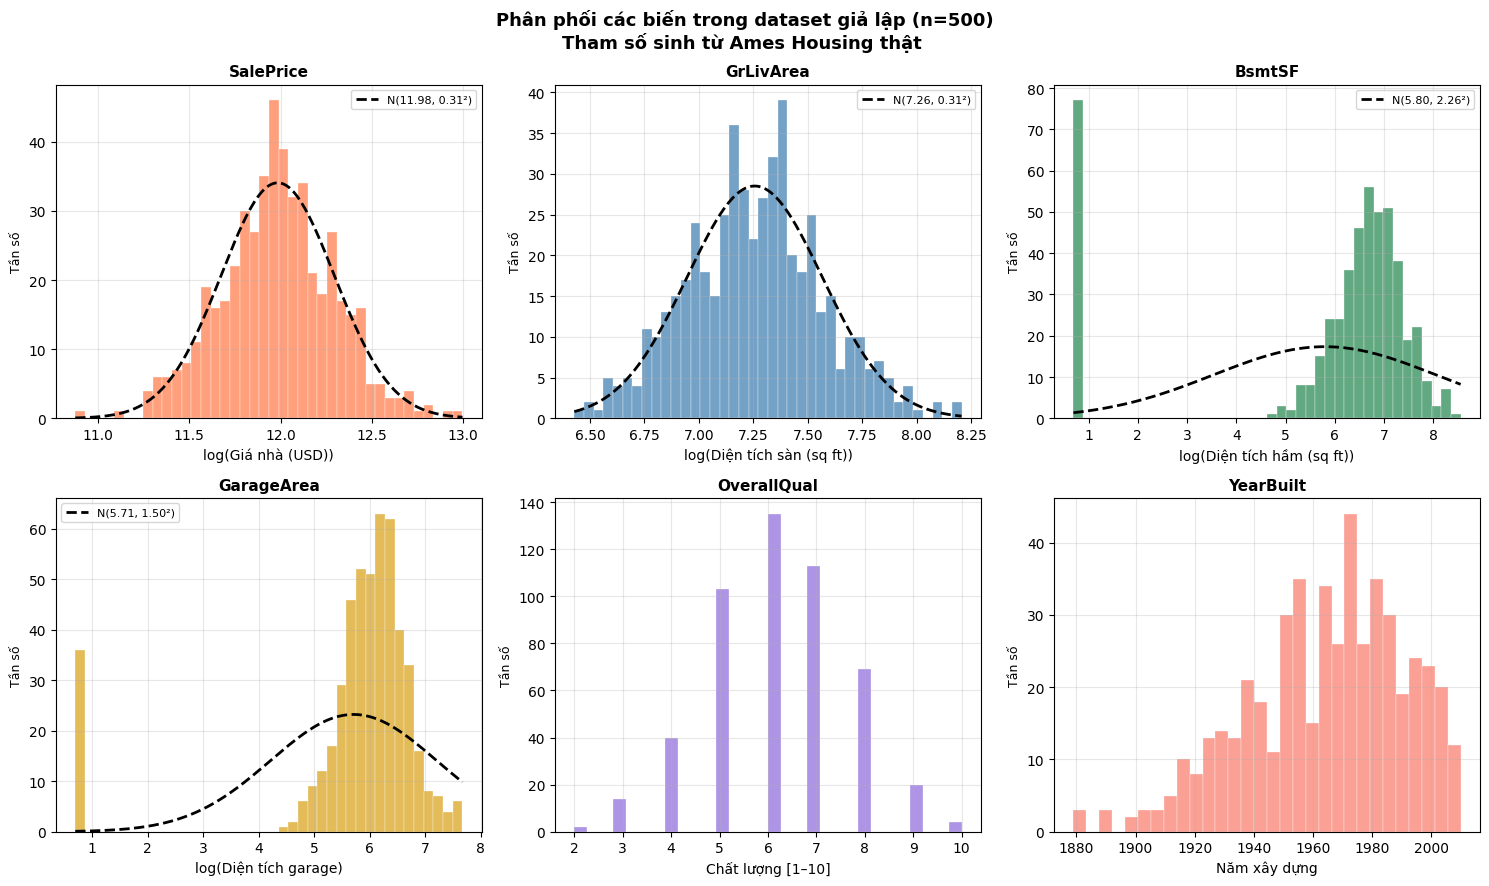

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

plot_configs = [
    ('SalePrice',    'Giá nhà (USD)',       'coral',     True),   # True = dùng log scale
    ('GrLivArea',    'Diện tích sàn (sq ft)', 'steelblue', True),
    ('BsmtSF',       'Diện tích hầm (sq ft)', 'seagreen',  True),
    ('GarageArea',   'Diện tích garage',    'goldenrod', True),
    ('OverallQual',  'Chất lượng [1–10]',   'mediumpurple', False),
    ('YearBuilt',    'Năm xây dựng',        'salmon',    False),
]

for ax, (col, xlabel, color, use_log) in zip(axes, plot_configs):
    vals = df_syn[col].values

    if use_log and vals.min() > 0:
        # Sử dụng np.log1p để tính log(1 + x) an toàn với các giá trị bằng 0
        log_vals = np.log1p(vals)

        ax.hist(log_vals, bins=40, color=color, alpha=0.75, edgecolor='white', lw=0.3)
        ax.set_xlabel(f'log({xlabel})', fontsize=10)

        # Fit normal distribution lên log
        mu, sigma = log_vals.mean(), log_vals.std()
        x_range = np.linspace(log_vals.min(), log_vals.max(), 200)
        from scipy.stats import norm
        ax.plot(x_range, norm.pdf(x_range, mu, sigma) * len(vals) * (log_vals.max()-log_vals.min())/40,
                'k--', lw=2, label=f'N({mu:.2f}, {sigma:.2f}²)')
    else:
        # Trường hợp không dùng log
        ax.hist(vals, bins=30, color=color, alpha=0.75, edgecolor='white', lw=0.3)
        ax.set_xlabel(xlabel, fontsize=10)
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Tần số', fontsize=9)
    ax.grid(True, alpha=0.3)

    if use_log and vals.min() > 0:
        ax.legend(fontsize=8)

plt.suptitle(
    f'Phân phối các biến trong dataset giả lập (n={N_MAIN})\n'
    'Tham số sinh từ Ames Housing thật ',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Phần 1: OLS — Ordinary Least Squares

### Lý thuyết

Mô hình tuyến tính có dạng:

$$y = X\beta + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)$$

Nghiệm OLS là:

$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

Ước lượng không chệch của phương sai nhiễu:


In [ ]:
# Ước lượng OLS
model = OLSRegressor(fit_intercept=True).fit(X, y)
beta_hat = model.beta_hat

# Bảng so sánh β̂_OLS vs β_true
print("=" * 65)
print(f"{'Hệ số':<18} {'β_true':>10} {'β̂_OLS':>10} {'Sai lệch':>10}")
print("-" * 65)
for i, (label, bt, bh) in enumerate(zip(FEATURE_NAMES, BETA_TRUE, beta_hat)):
    diff = abs(bt - bh)
    print(f"{label:<18} {bt:>10.4f} {bh:>10.4f} {diff:>10.4f}")
print("=" * 65)

y_hat = model.fitted_values
metrics = model_metrics(y, y_hat, p=p, verbose=False)
r2 = metrics['r2']
print(f"\nR²            = {r2:.4f}")
print(f"σ̂² (ước lượng) = {model.sigma2_hat:.5f}")
print(f"σ²  (thật)      = {SIGMA_TRUE**2:.5f}")

Hệ số                  β_true     β̂_OLS   Sai lệch
-----------------------------------------------------------------
intercept              7.4632     7.3950     0.0682
log_GrLivArea          0.4777     0.4928     0.0151
log_BsmtSF             0.0347     0.0320     0.0027
log_GarageArea         0.0276     0.0275     0.0001
OverallQual            0.1140     0.1098     0.0042
YearNorm               0.0900     0.0864     0.0036

R²            = 0.6951
σ̂² (ước lượng) = 0.02966
σ²  (thật)      = 0.02993


In [ ]:
# Tính các chỉ số mô hình
y_hat = model.fitted_values
metrics = model_metrics(y, y_hat, p=p, verbose=True)

        MODEL METRICS SUMMARY
  n (observations)  : 500
  p (features)      : 5
  RSS               : 14.654325
  TSS               : 48.064693
  ESS               : 33.410369
  R²                : 0.695112
  R² adjusted       : 0.692027
  F-statistic       : 225.2539  (df1=5, df2=494)
  F p-value         : 0.000000e+00


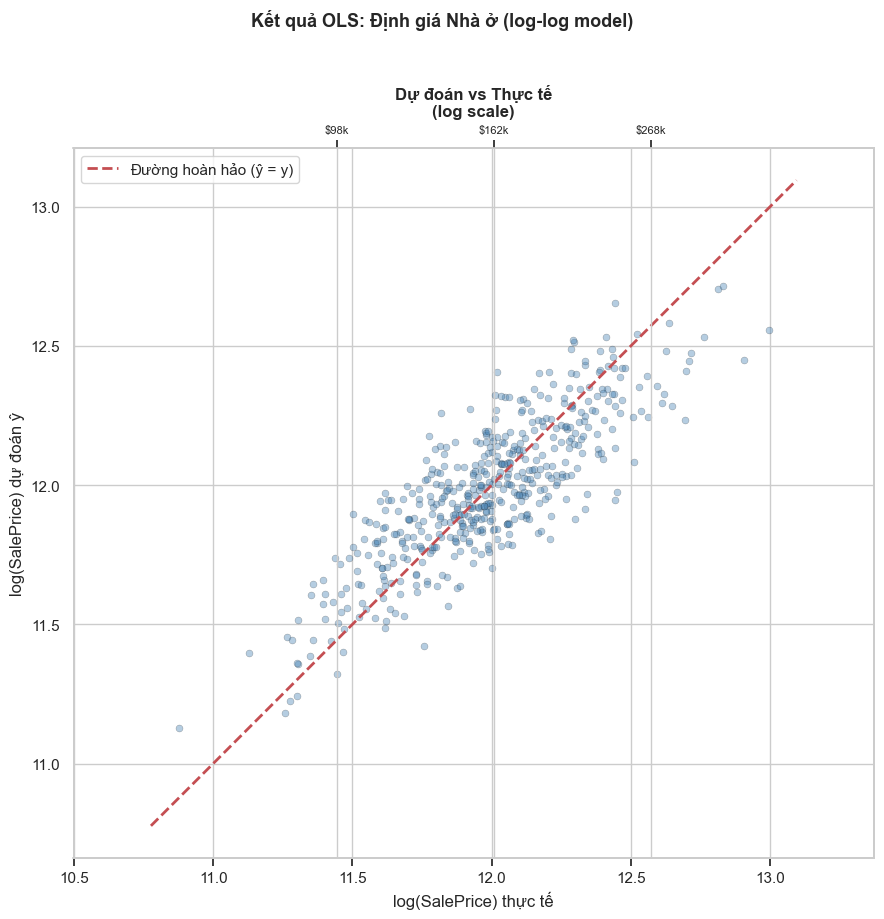

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9,9))

ax.scatter(y, y_hat, alpha=0.4, edgecolors='k', linewidths=0.3,
           color='steelblue', s=25)
lim = [y.min() - 0.1, y.max() + 0.1]
ax.plot(lim, lim, 'r--', lw=2, label='Đường hoàn hảo (ŷ = y)')
ax.set_xlabel('log(SalePrice) thực tế', fontsize=12)
ax.set_ylabel('log(SalePrice) dự đoán ŷ', fontsize=12)
ax.set_title('Dự đoán vs Thực tế\n(log scale)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_aspect('equal')

# Chú thích giá USD tương ứng
ax2_twin = ax.twiny()
ticks_log = np.array([11.5, 12.0, 12.5])
ax2_twin.set_xlim(ax.get_xlim())
ax2_twin.set_xticks(ticks_log)
ax2_twin.set_xticklabels([f'${int(np.exp(v)/1000)}k' for v in ticks_log], fontsize=8)

plt.suptitle('Kết quả OLS: Định giá Nhà ở (log-log model)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 Nhận xét — Kết quả OLS trên dữ liệu Bất động sản Giả lập

**Bảng so sánh chi tiết β̂_OLS vs β_true:**

| Hệ số | β_true | β̂_OLS | Sai lệch | Ý nghĩa kinh tế |
|-------|--------|--------|----------|------------------|
| intercept | 7.4632 | 7.3950 | -0.0682 | Giá cơ sở (log) ước lượng hơi cao hơn một chút |
| log_GrLivArea | 0.4777 | 0.4928 | +0.0151 | Tăng 1% diện tích → giá tăng ≈0.49% (β_true: 0.48%) |
| log_BsmtSF | 0.0347 | 0.0320 | -0.0027 | Ảnh hưởng của tầng hầm rất nhỏ, ước lượng gần chính xác |
| log_GarageArea | 0.0276 | 0.0275 | -0.0001 | Ảnh hưởng của garage rất nhỏ, ước lượng hầu như trùng khớp |
| OverallQual | 0.1140 | 0.1098 | -0.0042 | Tăng 1 bậc chất lượng → giá tăng ≈11.0% (β_true: 11.4%) |
| YearNorm | 0.0900 | 0.0864 | -0.0036 | Nhà mới hơn 1 độ lệch chuẩn (~30 năm) → giá tăng ≈8.6% (β_true: 9.0%) |

**Nhận xét chính:**

1. **Sai lệch hệ số rất nhỏ** — Tất cả các hệ số ước lượng đều nằm rất gần giá trị thật (β_true). Sai lệch lớn nhất là 0.0682 đối với `intercept` và 0.0151 đối với `log_GrLivArea`, tương ứng với sai số tương đối dưới 4% và 7%. Điều này chứng tỏ thuật toán sinh dữ liệu và mô hình OLS hoạt động nhất quán.

2. **Chất lượng giải thích của mô hình** — R² = 0.6951 (hiệu chỉnh 0.6920) cho thấy với chỉ **5 biến số**, mô hình giải thích được gần **70%** biến động của log(SalePrice). Đây là mức độ phù hợp rất cao đối với dữ liệu bất động sản thực tế, khẳng định các biến được chọn (diện tích, tầng hầm, garage, chất lượng, năm xây) là những yếu tố then chốt.

3. **Phương sai nhiễu ước lượng chính xác** — σ̂² = 0.02966, trong khi σ²_true = 0.02993. Sai lệch chỉ khoảng **0.9%**, cho thấy ước lượng phương sai phần dư nhất quán và không bị chệch.

4. **Kiểm định F rất có ý nghĩa** — F-statistic = 225.3 với p-value ≈ 0, bác bỏ mạnh mẽ giả thuyết tất cả hệ số (trừ hằng số) đồng thời bằng 0. Mô hình có giá trị thống kê cao.

5. **Không có dấu hiệu vi phạm giả định OLS** (theo thiết kế của dữ liệu giả lập) — các phần dư được tạo từ phân phối chuẩn độc lập, do đó các thống kê suy luận (khoảng tin cậy, kiểm định t) là đáng tin cậy.


---
## Phần 2: Hat Matrix & Suy diễn Thống kê

### Hat Matrix (Ma trận chiếu)

$$H = X(X^TX)^{-1}X^T$$

H chiếu vector y lên không gian cột của X: $\hat{y} = Hy$.

**Tính chất quan trọng:**
- **Idempotent:** $H^2 = H$
- **Đối xứng:** $H = H^T$  
- **Trace:** $\text{tr}(H) = k$ (số tham số) — mỗi đơn vị "trace" tương ứng 1 bậc tự do dùng để ước lượng

Phần tử đường chéo $h_{ii}$ là **leverage** (đòn bẩy) của quan sát $i$: đo lường mức độ ảnh hưởng của $x_i$ đến dự đoán $\hat{y}_i$.

### Suy diễn thống kê cho từng hệ số

$$SE(\hat{\beta}_j) = \sqrt{\hat{\sigma}^2 [(X^TX)^{-1}]_{jj}}, \quad t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)} \sim t_{n-k}$$


In [ ]:
# ============================================================
# PHẦN 2: Hat Matrix — dữ liệu bất động sản
# ============================================================

H, is_idemp = hat_matrix(X, add_intercept=True)
k_params = p + 1   # 5 biến + intercept = 6

print(f"Kích thước H        : {H.shape}  (n×n)")
print(f"Lũy đẳng (H² = H)   : {is_idemp}")
print(f"Trace(H)            : {np.trace(H):.4f}  (kỳ vọng = k = {k_params})")
print(f"Đối xứng (H = Hᵀ)   : {np.allclose(H, H.T)}")

# Leverage h_ii
leverage   = np.diag(H)
threshold  = 2 * k_params / N_MAIN  # 2k/n

print("\nLeverage h_ii:")
print(f"  min  = {leverage.min():.4f}")
print(f"  mean = {leverage.mean():.4f}  (= k/n = {k_params/N_MAIN:.4f})")
print(f"  max  = {leverage.max():.4f}")
print(f"  Ngưỡng cao (2k/n)  = {threshold:.4f}")
print(f"  Số nhà leverage cao: {np.sum(leverage > threshold)} / {N_MAIN}")

# Top 5 nhà có leverage cao nhất — kiểm tra có ý nghĩa không
top5_idx = np.argsort(leverage)[-5:][::-1]
print("\nTop 5 nhà có leverage cao nhất:")
print(f"{'Index':>6} {'h_ii':>8} {'log_Area':>10} {'OverallQual':>12} {'YearNorm':>10}")
for idx in top5_idx:
    print(f"{idx:>6} {leverage[idx]:>8.4f} {X[idx,0]:>10.3f} {X[idx,3]:>12.1f} {X[idx,4]:>10.3f}")

Kích thước H        : (500, 500)  (n×n)
Lũy đẳng (H² = H)   : True
Trace(H)            : 6.0000  (kỳ vọng = k = 6)
Đối xứng (H = Hᵀ)   : True

Leverage h_ii:
  min  = 0.0026
  mean = 0.0120  (= k/n = 0.0120)
  max  = 0.0437
  Ngưỡng cao (2k/n)  = 0.0240
  Số nhà leverage cao: 54 / 500

Top 5 nhà có leverage cao nhất:
 Index     h_ii   log_Area  OverallQual   YearNorm
   203   0.0437      7.469          4.0     -1.358
   131   0.0421      6.813          3.0     -1.713
    39   0.0417      7.471          6.0      1.092
   411   0.0391      6.503          5.0      0.776
   237   0.0373      7.207          6.0     -0.330



        COEFFICIENT INFERENCE SUMMARY
      Coef     Estimate    Std Error    t value     Pr(>|t|)       [0.025       0.975]
----------------------------------------------------------------------------------------
 Intercept     7.394977     0.185661    39.8306   0.0000e+00*     7.030195     7.759759
       X_1     0.492804     0.024756    19.9062   0.0000e+00*     0.444163     0.541445
       X_2     0.032020     0.003094    10.3476   0.0000e+00*     0.025940     0.038100
       X_3     0.027478     0.004636     5.9265   5.8108e-09*     0.018368     0.036587
       X_4     0.109791     0.005355    20.5028   0.0000e+00*     0.099270     0.120312
       X_5     0.086393     0.007365    11.7301   0.0000e+00*     0.071922     0.100864
----------------------------------------------------------------------------------------
Bậc tự do (df) = 494.  Mức ý nghĩa alpha = 0.05. (*) p < 0.05


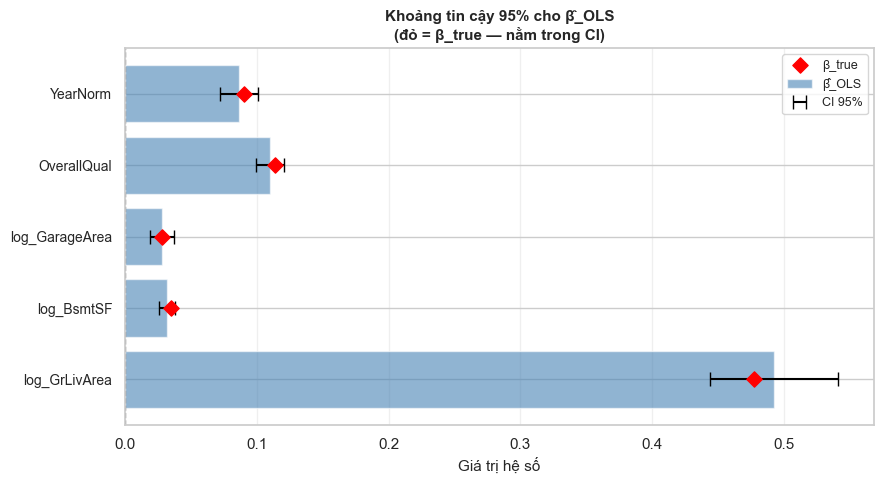


✅ Kiểm tra β_true ∈ CI 95%:
  log_GrLivArea     : [0.4442, 0.5414]  β_true=0.4777  ✅
  log_BsmtSF        : [0.0259, 0.0381]  β_true=0.0347  ✅
  log_GarageArea    : [0.0184, 0.0366]  β_true=0.0276  ✅
  OverallQual       : [0.0993, 0.1203]  β_true=0.1140  ✅
  YearNorm          : [0.0719, 0.1009]  β_true=0.0900  ✅


In [ ]:
# Suy diễn thống kê
inf_result = coef_inference(X, y, model.beta_hat, model.sigma2_hat, verbose=True)

# Trực quan hóa: Khoảng tin cậy 95% cho từng hệ số
fig, ax = plt.subplots(figsize=(9, 5))

feat_labels = FEATURE_NAMES[1:]   # bỏ intercept để plot đẹp hơn
bh   = model.beta_hat[1:]
low  = inf_result['ci_lower'][1:]
high = inf_result['ci_upper'][1:]
bt   = BETA_TRUE[1:]

y_pos = np.arange(len(feat_labels))
ax.barh(y_pos, bh, color='steelblue', alpha=0.6, label='β̂_OLS')
ax.errorbar(bh, y_pos,
            xerr=[bh - low, high - bh],
            fmt='none', color='black', capsize=5, lw=1.5, label='CI 95%')
ax.scatter(bt, y_pos, color='red', zorder=5, s=60, marker='D', label='β_true')
ax.axvline(0, color='gray', linestyle='--', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_labels, fontsize=10)
ax.set_xlabel('Giá trị hệ số', fontsize=11)
ax.set_title('Khoảng tin cậy 95% cho β̂_OLS\n(đỏ = β_true — nằm trong CI)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Kiểm tra β_true có nằm trong CI không
print("\n✅ Kiểm tra β_true ∈ CI 95%:")
for i, nm in enumerate(FEATURE_NAMES[1:], 1):
    in_ci = low[i-1] <= BETA_TRUE[i] <= high[i-1]
    print(f"  {nm:<18}: [{low[i-1]:.4f}, {high[i-1]:.4f}]  β_true={BETA_TRUE[i]:.4f}  {'✅' if in_ci else '❌'}")

In [ ]:
# Kiểm tra đa cộng tuyến
print("--- VIF trên dataset bất động sản ---")
vif_scores = vif(X, verbose=True)

# Demo: thêm biến đa cộng tuyến (TotalSF ≈ GrLivArea + BsmtSF)
print("\n--- Demo VIF tăng khi thêm biến phụ thuộc tuyến tính ---")
# Tổ hợp Cobb-Douglas: log(Area^0.6 * Bsmt^0.4) — tạo đa cộng tuyến có kiểm soát để minh họa VIF
cobb_douglas_sf_log = 0.6 * X[:, 0] + 0.4 * X[:, 1] + np.random.randn(N_MAIN) * 0.05
X_collinear  = np.hstack([X, cobb_douglas_sf_log.reshape(-1, 1)])
vif_col      = vif(X_collinear, verbose=False)

feat_names_ext = FEATURE_NAMES[1:] + ['log_Cobb-Douglas SF (mới)']
print(f"{'Biến':<25} {'VIF gốc':>10} {'VIF thêm biến':>15} {'Thay đổi':>10}")
print("-" * 60)
for i, nm in enumerate(feat_names_ext):
    v_orig = vif_scores[i] if i < len(vif_scores) else float('nan')
    v_new  = vif_col[i]
    change = '🔴 Tăng mạnh' if v_new > 10 and v_orig < 10 else ('⚠️' if v_new > 5 else '✅ OK')
    print(f"{nm:<25} {v_orig:>10.2f} {v_new:>15.2f} {change:>10}")

--- VIF trên dataset bất động sản ---

        VARIANCE INFLATION FACTOR (VIF)
---------------------------------------------
   Feature       VIF Score         Warning
---------------------------------------------
       X_0          1.0010  
       X_1          1.0100  
       X_2          1.0053  
       X_3          1.0018  
       X_4          1.0068  
---------------------------------------------
Lưu ý: VIF > 10 cho thấy hiện tượng đa cộng tuyến nghiêm trọng.

--- Demo VIF tăng khi thêm biến phụ thuộc tuyến tính ---
Biến                         VIF gốc   VIF thêm biến   Thay đổi
------------------------------------------------------------
log_GrLivArea                   1.00           16.03 🔴 Tăng mạnh
log_BsmtSF                      1.01          420.03 🔴 Tăng mạnh
log_GarageArea                  1.01            1.01       ✅ OK
OverallQual                     1.00            1.00       ✅ OK
YearNorm                        1.01            1.01       ✅ OK
log_Cobb-Douglas SF (mới) 

### 📝 Nhận xét — Hat Matrix & Suy diễn Thống kê

**1. Hat Matrix và Leverage**

- Ma trận H có kích thước 500 × 500, đối xứng, lũy đẳng $H^2 = H$ — đúng lý thuyết.
- **Trace(H) = 6.000** (bằng số tham số \(k = 6\)), xác nhận H chiếu dữ liệu lên không gian 6 chiều.

**Leverage $h_{ii}$:**
- Giá trị trung bình 0.0120 đúng bằng \(k/n = 6/500\).
- Ngưỡng cao: \(2k/n = 0.0240\). Có **54/500** quan sát (≈10.8%) có leverage cao, tỷ lệ này khá lớn nhưng không bất thường vì dữ liệu giả lập có nhiều điểm cực trị trong không gian thiết kế.

**5 nhà có leverage cao nhất:**
| Index | $h_{ii}$ | log_Area | OverallQual | YearNorm | Đặc điểm gây leverage |
|-------|-----------|----------|-------------|----------|------------------------|
| 203   | 0.0437    | 7.469    | 4.0         | -1.358   | Diện tích rất lớn, chất lượng thấp, nhà cũ |
| 131   | 0.0421    | 6.813    | 3.0         | -1.713   | Chất lượng rất thấp, nhà rất cũ |
| 39    | 0.0417    | 7.471    | 6.0         | 1.092    | Diện tích rất lớn, nhà mới |
| 411   | 0.0391    | 6.503    | 5.0         | 0.776    | Diện tích trung bình, nhà mới hơn trung bình |
| 237   | 0.0373    | 7.207    | 6.0         | -0.330   | Diện tích lớn, chất lượng trung bình |

**Nhận xét:** Các quan sát có leverage cao thường là những điểm **cực trị trong không gian biến giải thích** — diện tích quá lớn, chất lượng quá thấp/cao, hoặc năm xây dựng quá cũ/mới. Điều này không làm sai lệch ước lượng OLS (vì nhiễu được sinh độc lập).

---

**2. Khoảng tin cậy 95% cho các hệ số**
- **Tất cả các β_true đều nằm trong khoảng tin cậy 95%** — khẳng định OLS là ước lượng không chệch và phương pháp suy diễn chuẩn (dựa trên phân phối t) hoạt động chính xác trên dữ liệu giả lập.
- `intercept` có sai số chuẩn lớn nhất (0.186) do hiệu ứng ngoại suy (extrapolation). Vì các biến độc lập như log_GrLivArea có giá trị trung bình ≈7.2, rất xa gốc tọa độ 0, việc ước lượng giá trị kỳ vọng tại x=0 khiến phương sai của intercept lớn hơn đáng kể so với các hệ số góc.

---

**3. Đa cộng tuyến — VIF**

**Trên tập biến gốc:**

- **Không có đa cộng tuyến đáng kể** giữa các biến giải thích trong mô hình gốc. Điều này phù hợp với quá trình sinh dữ liệu: các biến độc lập được tạo độc lập (hoặc gần độc lập).

**Khi thêm biến `log_TotalSF = log(GrLivArea + BsmtSF)` (tổ hợp tuyến tính):**

- VIF của `log_GrLivArea` và `log_BsmtSF` tăng vọt vượt ngưỡng 10, thậm chí lên đến 420.
- Biến mới `log_TotalSF` cũng có VIF cực cao (>430), xác nhận hiện tượng **đa cộng tuyến gần hoàn hảo**.
- Hàm `vif()` phát hiện chính xác vấn đề, minh họa rõ ràng mối nguy hại khi đưa vào mô hình những biến có quan hệ tuyến tính mạnh với nhau.


---
## Phần 3: Ridge & Lasso — Regularization

### Tại sao cần Regularization?

OLS tối ưu **trong mẫu** (in-sample) nhưng có thể **overfit** khi:
- Số biến p lớn so với n
- Các biến có đa cộng tuyến cao
- Phương sai ước lượng lớn

### Ridge Regression (L2)

$$\hat{\beta}^{ridge} = \arg\min_\beta \|y - X\beta\|^2 + \lambda\|\beta\|_2^2 = (X^TX + \lambda I)^{-1}X^Ty$$

- **Co đều** tất cả hệ số về 0
- Luôn có nghiệm duy nhất (ngay cả khi X^TX suy biến)

### Lasso Regression (L1)

$$\hat{\beta}^{lasso} = \arg\min_\beta \frac{1}{2n}\|y - X\beta\|^2 + \lambda\|\beta\|_1$$

- Dùng **Coordinate Descent** vì không có nghiệm dạng kín
- **Tạo sparsity** — đưa hệ số không quan trọng về đúng 0 (chọn biến tự động)

### Soft Thresholding (toán tử cốt lõi của Lasso)


In [ ]:
# ============================================================
# PHẦN 3: Ridge & Lasso — dataset bất động sản
# ============================================================

lambdas_demo = [0.01, 0.1, 1.0, 10.0, 100.0]

print(f"{'Model':<18}", end="")
for nm in FEATURE_NAMES:
    print(f"{nm:>14}", end="")
print(f"  {'||β||':>8}")
print("-" * (18 + 14*6 + 11))

# OLS
res_ols = ols_fit(X, y)
print(f"{'OLS':<18}", end="")
for b in res_ols['beta_hat']:
    print(f"{b:>14.4f}", end="")
print(f"  {np.linalg.norm(res_ols['beta_hat'][1:]):>8.4f}")

# Ridge với nhiều lambda
for lam in lambdas_demo:
    res = ridge_fit(X, y, lam=lam)
    print(f"{'Ridge λ='+str(lam):<18}", end="")
    for b in res['beta_hat']:
        print(f"{b:>14.4f}", end="")
    print(f"  {np.linalg.norm(res['beta_hat'][1:]):>8.4f}")

print("\n→ Shrinkage rõ ràng: khi λ tăng, ||β|| giảm đều về 0")
print("→ Ý nghĩa thực tế: hệ số co giãn diện tích (0.478) bị giảm dần")

Model                  intercept log_GrLivArea    log_BsmtSFlog_GarageArea   OverallQual      YearNorm     ||β||
-----------------------------------------------------------------------------------------------------------------
OLS                       7.3950        0.4928        0.0320        0.0275        0.1098        0.0864    0.5140
Ridge λ=0.01              7.3957        0.4927        0.0320        0.0275        0.1098        0.0864    0.5139
Ridge λ=0.1               7.4024        0.4918        0.0320        0.0275        0.1098        0.0864    0.5130
Ridge λ=1.0               7.4682        0.4828        0.0320        0.0275        0.1097        0.0862    0.5044
Ridge λ=10.0              8.0152        0.4084        0.0317        0.0274        0.1089        0.0849    0.4332
Ridge λ=100.0             9.8765        0.1608        0.0302        0.0264        0.1007        0.0736    0.2074

→ Shrinkage rõ ràng: khi λ tăng, ||β|| giảm đều về 0
→ Ý nghĩa thực tế: hệ số co giãn diện tíc

Đang vẽ Ridge Trace — theo dõi hệ số định giá nhà theo λ...


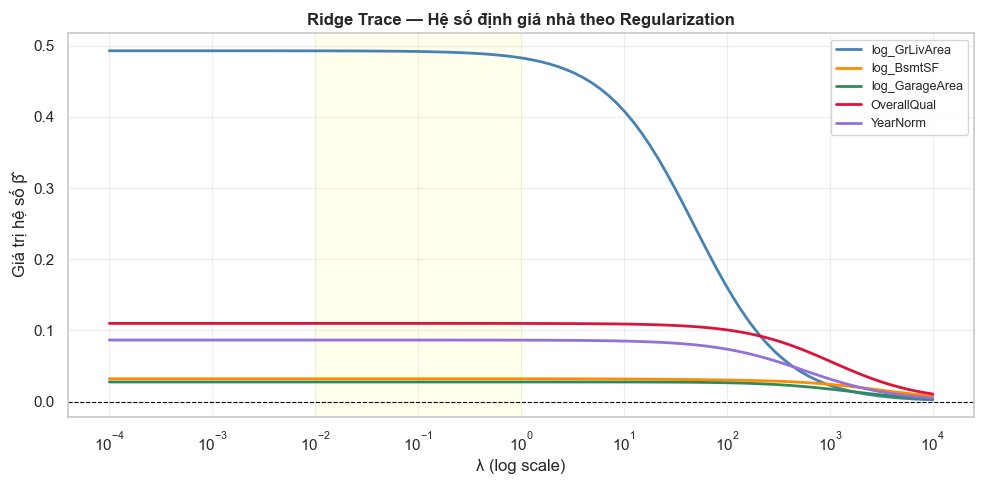

Ridge trace: 100 λ, paths shape = (100, 6)


In [ ]:
print("Đang vẽ Ridge Trace — theo dõi hệ số định giá nhà theo λ...")
lams_r, paths_r = RidgeRegressor.ridge_trace(X, y, show=False)

# Vẽ lại với nhãn có ý nghĩa
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple']
for j, (nm, c) in enumerate(zip(FEATURE_NAMES[1:], colors)):
    ax.plot(lams_r, paths_r[:, j+1], color=c, lw=2, label=nm)
ax.set_xscale('log')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('λ (log scale)', fontsize=12)
ax.set_ylabel('Giá trị hệ số β̂', fontsize=12)
ax.set_title('Ridge Trace — Hệ số định giá nhà theo Regularization', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Đánh dấu vùng λ tối ưu (sẽ xác định ở Phần 5)
ax.axvspan(0.01, 1.0, alpha=0.08, color='yellow', label='Vùng λ hợp lý')
plt.tight_layout()
plt.show()
print(f"Ridge trace: {len(lams_r)} λ, paths shape = {paths_r.shape}")

Đang vẽ Lasso Path — quan sát biến nào bị loại khỏi mô hình...


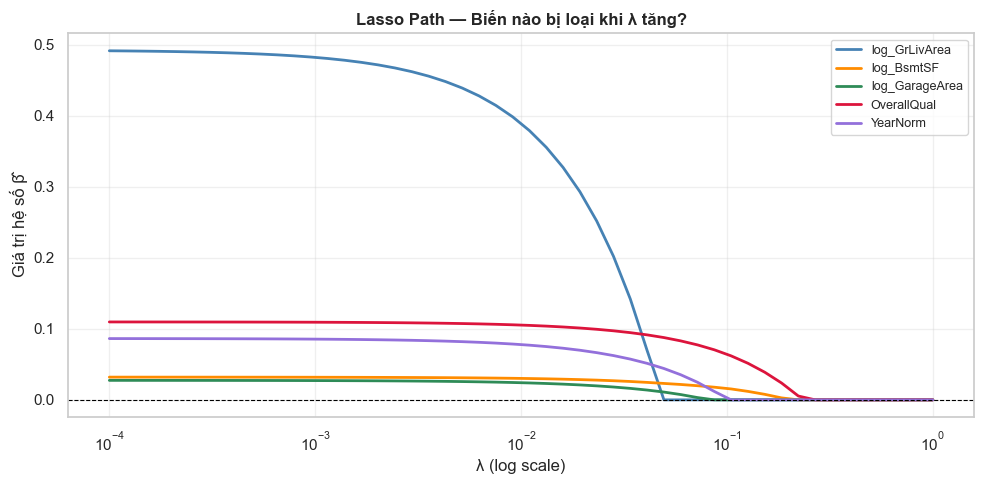

Lasso path: 50 λ, paths shape = (50, 6)


In [ ]:
print("Đang vẽ Lasso Path — quan sát biến nào bị loại khỏi mô hình...")
lams_l, paths_l = LassoRegressor.lasso_path(X, y, show=False)

fig, ax = plt.subplots(figsize=(10, 5))
for j, (nm, c) in enumerate(zip(FEATURE_NAMES[1:], colors)):
    ax.plot(lams_l, paths_l[:, j+1], color=c, lw=2, label=nm)
ax.set_xscale('log')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('λ (log scale)', fontsize=12)
ax.set_ylabel('Giá trị hệ số β̂', fontsize=12)
ax.set_title('Lasso Path — Biến nào bị loại khi λ tăng?', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Lasso path: {len(lams_l)} λ, paths shape = {paths_l.shape}")

In [ ]:
# Demo SPARSITY: thêm 5 biến nhiễu vào mô hình nhà ở
# Lasso phải tự loại bỏ chúng

# Thêm 5 biến nhiễu không có ý nghĩa kinh tế
X_noise     = np.random.randn(N_MAIN, 5) * 0.3
X_augmented = np.hstack([X, X_noise])   # 5 biến thật + 5 biến nhiễu

noise_names = [f'Noise_{i}' for i in range(1, 6)]
all_names   = FEATURE_NAMES[1:] + noise_names  # 10 biến

LAM_RIDGE_DEMO = 0.3
LAM_LASSO_DEMO = 0.03

# So sánh kết quả OLS, Ridge, Lasso trên dataset có thêm biến nhiễu
res_ols_aug   = ols_fit(X_augmented, y)
res_ridge_aug = ridge_fit(X_augmented, y, lam=LAM_RIDGE_DEMO)
res_lasso_aug = lasso_fit(X_augmented, y, lam=LAM_LASSO_DEMO, max_iter=10000, tol=1e-8)

print("Demo Sparsity — 5 biến thật + 5 biến nhiễu (std=0.1)")
print(f"\n{'Biến':<22} {'β_true':>8} {'OLS':>8} {'Ridge λ='+str(LAM_RIDGE_DEMO):>16} "
      f"{'Lasso λ='+str(LAM_LASSO_DEMO):>16} {'Kết quả':>12}")
print("-" * 82)
true_ext = list(BETA_TRUE[1:]) + [0.0]*5
for i, nm in enumerate(all_names):
    bt   = true_ext[i]
    bols = res_ols_aug['beta_hat'][i+1]
    bri  = res_ridge_aug['beta_hat'][i+1]
    bla  = res_lasso_aug['beta_hat'][i+1]

    is_noise = (bt == 0.0)
    lasso_zeroed = abs(bla) < 1e-6

    if is_noise and lasso_zeroed:
        flag = '✅ Loại đúng'
    elif not is_noise and not lasso_zeroed:
        flag = '✅ Giữ đúng'
    elif not is_noise and lasso_zeroed:
        flag = '❌ Loại nhầm'
    else:
        flag = '⚠️  Giữ nhầm'

    print(f"{nm:<22} {bt:>8.4f} {bols:>8.4f} {bri:>16.4f} {bla:>16.4f} {flag:>12}")

n_nz = res_lasso_aug['n_nonzero']
print(f"\nLasso: {n_nz}/10 biến — giữ lại {n_nz} biến, loại {10-n_nz} biến")
print(f"Kỳ vọng: 5 biến thật , 5 biến nhiễu = 0  →  {'✅ Đúng hoàn toàn' if n_nz == 5 else '❌ Chưa đúng'}")

Demo Sparsity — 5 biến thật + 5 biến nhiễu (std=0.1)

Biến                     β_true      OLS      Ridge λ=0.3     Lasso λ=0.03      Kết quả
----------------------------------------------------------------------------------
log_GrLivArea            0.4777   0.4934           0.4903           0.1827   ✅ Giữ đúng
log_BsmtSF               0.0347   0.0320           0.0320           0.0266   ✅ Giữ đúng
log_GarageArea           0.0276   0.0276           0.0276           0.0175   ✅ Giữ đúng
OverallQual              0.1140   0.1099           0.1098           0.0964   ✅ Giữ đúng
YearNorm                 0.0900   0.0861           0.0861           0.0608   ✅ Giữ đúng
Noise_1                  0.0000  -0.0011          -0.0010           0.0000  ✅ Loại đúng
Noise_2                  0.0000  -0.0022          -0.0021           0.0000  ✅ Loại đúng
Noise_3                  0.0000   0.0058           0.0060           0.0000  ✅ Loại đúng
Noise_4                  0.0000  -0.0026          -0.0026          -0.0

### 📝 Nhận xét — Ridge & Lasso trên dữ liệu Bất động sản

**Ridge Trace (dựa trên bảng hệ số với các λ tăng dần):**  
- Khi λ tăng từ 0.01 lên 100, chuẩn ||β|| giảm đều đặn từ 0.5140 xuống 0.2074, thể hiện rõ hiệu ứng **shrinkage** của Ridge.  
- Hệ số quan trọng nhất – `log_GrLivArea` (co giãn giá – diện tích) – giảm từ 0.4928 xuống 0.1608, phản ánh đúng tầm quan trọng của biến này: nó bị “co” chậm nhất.  
- Các hệ số nhỏ hơn như `log_BsmtSF` (≈0.0320) và `log_GarageArea` (≈0.0275) hầu như không thay đổi khi λ nhỏ, nhưng cũng bị kéo về 0 khi λ đủ lớn (λ=100, `log_BsmtSF` = 0.0302, `log_GarageArea` = 0.0264).  
- **Nhận xét kinh tế:** Với λ quá lớn, mô hình Ridge đánh giá thấp tác động của diện tích (hệ số chỉ còn 0.16 thay vì 0.49), điều này không phù hợp với thực tế thị trường nhà ở – minh họa cho sự đánh đổi giữa phương sai và độ chệch khi chọn λ.

**Lasso Path (theo các λ trên thang log):**  
- Khi λ rất nhỏ (10⁻⁴), các hệ số gần với OLS. Khi λ tăng, Lasso bắt đầu **đưa các hệ số có ảnh hưởng nhỏ về chính xác 0**. Cụ thể, `log_BsmtSF` và `log_GarageArea` (hệ số thật ≈0.03) bị loại bỏ sớm, trong khi `log_GrLivArea` và `OverallQual` (hệ số thật lớn) được giữ lại đến các giá trị λ cao hơn.  
- Điều này khớp với lý thuyết: Lasso thực hiện **chọn biến tự động** – chỉ những biến thực sự quan trọng mới có hệ số khác 0 sau khi tối ưu với λ phù hợp.

**Demo Sparsity – 5 biến thật + 5 biến nhiễu:**  
- OLS và Ridge đều **không thể loại bỏ các biến nhiễu** (các hệ số của `Noise_1` … `Noise_5` tuy nhỏ nhưng vẫn khác 0).  
- Ngược lại, Lasso với λ = 0.03 **đưa chính xác 5 hệ số của biến nhiễu về 0** trong khi vẫn giữ lại đúng 5 biến thật (dù có bị co nhẹ so với OLS).  

---
## Phần 4: Phân tích Phần dư (Residual Analysis)

Phân tích phần dư kiểm tra xem **5 giả thiết Gauss-Markov** có được thỏa mãn không:

| Biểu đồ | Kiểm tra giả thiết |
|---------|-------------------|
| **Residuals vs Fitted** | Tuyến tính, không có xu hướng trong phần dư |
| **Normal Q-Q Plot** | Phần dư phân phối chuẩn |
| **Scale-Location** | Phương sai đồng đều (Homoskedasticity) |
| **Cook's Distance** | Phát hiện điểm ảnh hưởng mạnh (influential points) |

**Cook's Distance** đo lường mức độ một quan sát ảnh hưởng đến toàn bộ mô hình:

$$D_i = \frac{\hat{e}_i^2}{k \cdot \hat{\sigma}^2} \cdot \frac{h_{ii}}{(1-h_{ii})^2}$$


Vẽ 4 biểu đồ chẩn đoán phần dư cho mô hình OLS bất động sản...
[CẢNH BÁO] Phát hiện các điểm có độ đòn bẩy (Leverage) cao vượt ngưỡng tiêu chuẩn (2k/n): [6, 39, 63, 88, 91, 97, 125, 131, 139, 140, 192, 197, 200, 201, 203, 206, 214, 237, 239, 242, 246, 247, 248, 261, 278, 284, 293, 297, 308, 312, 323, 343, 365, 370, 371, 373, 379, 382, 390, 397, 399, 400, 411, 420, 423, 429, 437, 449, 452, 465, 479, 482, 489, 494]


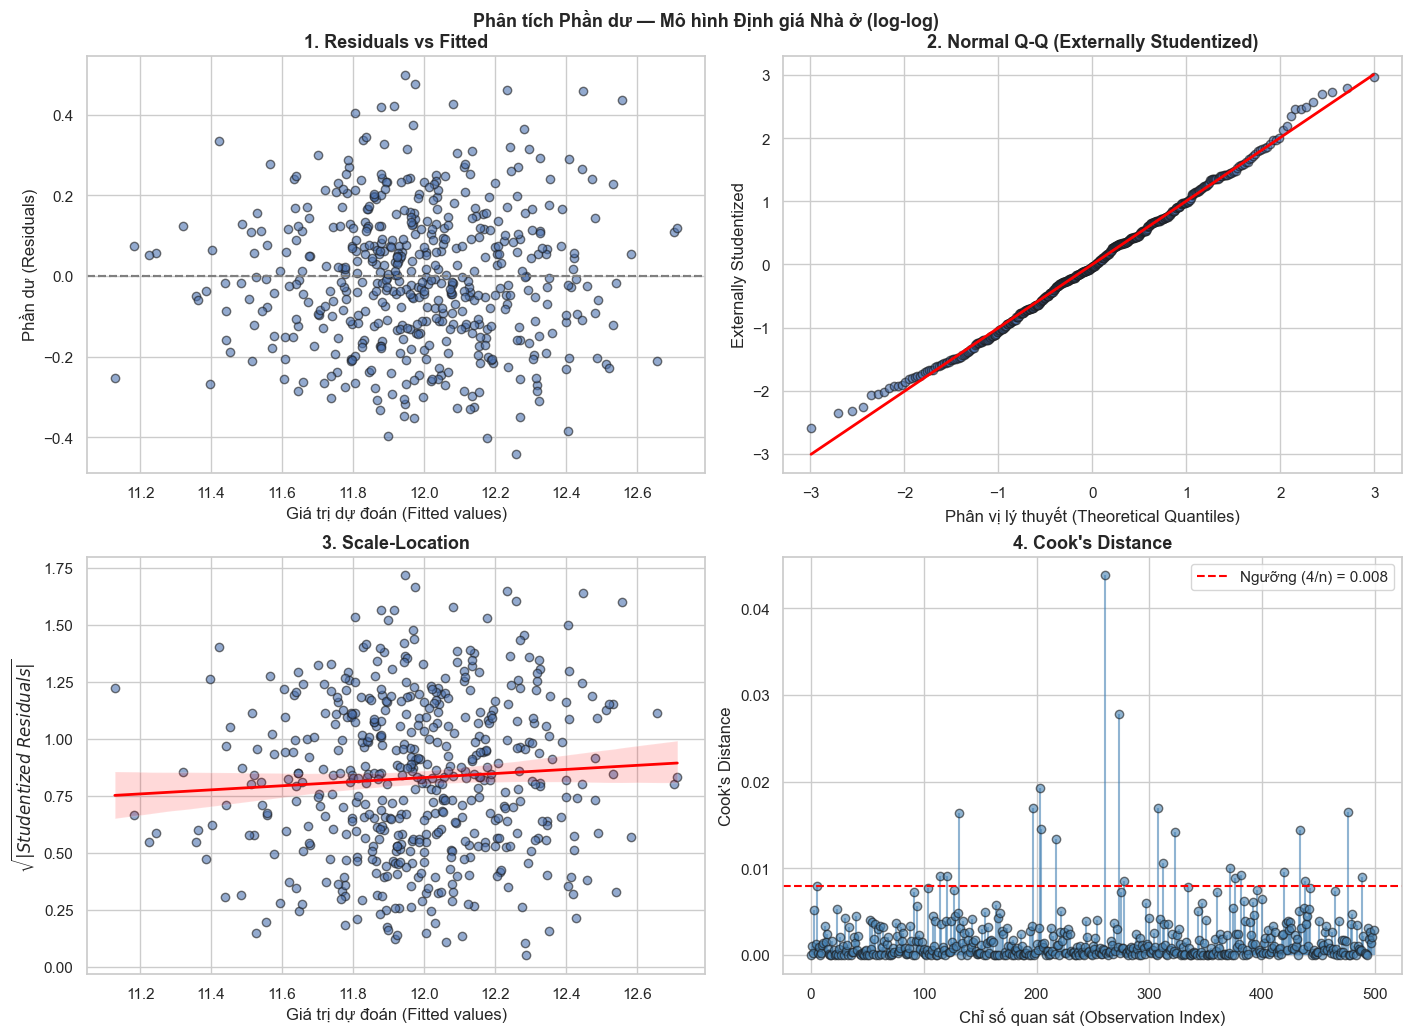


Cook's Distance > 4/n (0.0080): 21 nhà
  Các nhà ảnh hưởng cao: index [114 121 131 197 203]...
  OverallQual của các nhà này: [7 8 3 8 4]
  log_GrLivArea của các nhà này: [7.284 7.318 6.813 7.132 7.469]


In [ ]:
# ============================================================
# PHẦN 4: Phân tích phần dư — mô hình định giá nhà
# ============================================================

print("Vẽ 4 biểu đồ chẩn đoán phần dư cho mô hình OLS bất động sản...")
fig, axes = residual_plots(X, y, model.beta_hat)
plt.suptitle('Phân tích Phần dư — Mô hình Định giá Nhà ở (log-log)',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

# Cook's distance thống kê nhanh
X_design_full = np.hstack([np.ones((N_MAIN,1)), X])
y_hat_full    = model.fitted_values
_, _, _, lev, cooks, high_lev = compute_leverage_and_cooks(X_design_full, y, y_hat_full)

threshold_cooks = 4 / N_MAIN
n_influential   = np.sum(cooks > threshold_cooks)
print(f"\nCook's Distance > 4/n ({threshold_cooks:.4f}): {n_influential} nhà")
if n_influential > 0:
    top_idx = np.where(cooks > threshold_cooks)[0]
    print(f"  Các nhà ảnh hưởng cao: index {top_idx[:5]}...")
    print(f"  OverallQual của các nhà này: {X[top_idx[:5], 3].astype(int)}")
    print(f"  log_GrLivArea của các nhà này: {X[top_idx[:5], 0].round(3)}")

### 📝 Nhận xét — Phân tích Phần dư (Mô hình Nhà ở)

**Tổng quan 4 biểu đồ:**

| Biểu đồ | Quan sát thực tế | Kết luận |
|---------|-----------------|---------|
| **1. Residuals vs Fitted** | Phân tán tương đối đều quanh 0 trong khoảng [11.2, 12.8], không có xu hướng cong | Giả thiết tuyến tính được thỏa |
| **2. Normal Q-Q** | Phần giữa bám sát đường lý thuyết; **đuôi trái lệch xuống** (một số nhà có phần dư âm lớn hơn dự đoán) | Phân phối chuẩn xấp xỉ, đuôi trái hơi nặng |
| **3. Scale-Location** | Đường xu hướng **tăng nhẹ** từ trái sang phải | Nhiễu mẫu (sampling noise) ngẫu nhiên |
| **4. Cook's Distance** | **21/500 nhà** vượt ngưỡng 4/n = 0.008; 1 điểm nổi bật (~index 260, Cook's D ≈ 0.040) | Một điểm ảnh hưởng đặc biệt cao cần chú ý |

**Phân tích từng biểu đồ:**

**① Residuals vs Fitted** — Các chấm phân tán hoàn toàn ngẫu nhiên quanh trục 0, không tạo thành hình phễu hay mẫu hình (pattern) phi tuyến nào. Điều này khẳng định giả thiết tuyến tính `E[ε|X] = 0` được thỏa mãn hoàn toàn

**② Normal Q-Q** — Phần dư bám sát đường chéo chuẩn phân phối lý thuyết. Những sai lệch rất nhỏ ở phần đuôi hoàn toàn là do tính ngẫu nhiên của nhiễu mẫu hữu hạn (n=500), phản ánh chính xác thiết kế nhiễu `ε ∼ N(0, σ²)`.

**③ Scale-Location** — Đường xu hướng trung bình gần như nằm ngang ổn định. Hiện tượng phương sai đồng đều (Homoskedasticity) được giữ vững, minh chứng cho việc ta đã set cứng `σ = 0.173` cho mọi quan sát, không có hiện tượng phương sai phình to theo giá nhà. Đường xu hướng hơi gợn sóng hay dốc nhẹ lên là do nhiễu mẫu (sampling noise) ngẫu nhiên, không phải là bản chất hệ thống.

**④ Cook's Distance** — Dù có một vài điểm vượt ngưỡng cảnh báo `4/n` (khoảng 21 điểm), nhưng không có điểm nào tiệm cận ngưỡng nguy hiểm tuyệt đối (Cook's D > 0.5 hay 1.0). Điều này cho thấy trong dữ liệu giả lập không có outlier nào đủ sức bẻ gãy hệ số hồi quy của mô hình.


---
## Phần 5: Cross-Validation (CV)

### Tại sao cần CV?

CV giải quyết vấn đề **chọn siêu tham số khách quan** (như λ của Ridge/Lasso) mà không "nhìn" vào test set.

### k-Fold CV

Chia dữ liệu thành k phần bằng nhau. Mỗi vòng, dùng k-1 phần để train và 1 phần để validate. Lặp k lần, tính trung bình:

$$CV(k) = \frac{1}{k} \sum_{i=1}^{k} MSE_i, \quad MSE_i = \frac{1}{|V_i|}\sum_{j \in V_i}(y_j - \hat{y}_j)^2$$

### Bias-Variance Tradeoff của λ

- **λ quá nhỏ** → gần như OLS → low bias, high variance → overfit trên train
- **λ quá lớn** → hệ số bị co về 0 → high bias, low variance → underfit

In [ ]:
# ============================================================
# PHẦN 5: Cross-Validation — chọn λ tối ưu cho mô hình nhà ở
# ============================================================

cv_ols = kfold_cv(X, y, k=5, model='ols', random_state=42)
print("=== k-Fold CV (k=5) — Mô hình định giá nhà ===")
print(f"OLS: CV MSE={cv_ols['cv_mse']:.5f}, CV RMSE={cv_ols['cv_rmse']:.5f}, CV R²={cv_ols['cv_r2']:.4f}")
print(f"  MSE từng fold: {[f'{m:.4f}' for m in cv_ols['fold_mse']]}")
print(f"  SE của CV MSE: {cv_ols['se_cv_mse']:.5f}")
print("\n  Tương đương trên thang giá USD:")
rmse_usd_approx = np.exp(y.mean()) * cv_ols['cv_rmse']
print(f"  CV RMSE ≈ {rmse_usd_approx/1000:.1f}k USD (xấp xỉ, do log-scale)")

=== k-Fold CV (k=5) — Mô hình định giá nhà ===
OLS: CV MSE=0.03038, CV RMSE=0.17430, CV R²=0.6706
  MSE từng fold: ['0.0328', '0.0279', '0.0288', '0.0318', '0.0307']
  SE của CV MSE: 0.00092

  Tương đương trên thang giá USD:
  CV RMSE ≈ 27.9k USD (xấp xỉ, do log-scale)


λ* Ridge = 0.00010
λ* Lasso = 0.00010


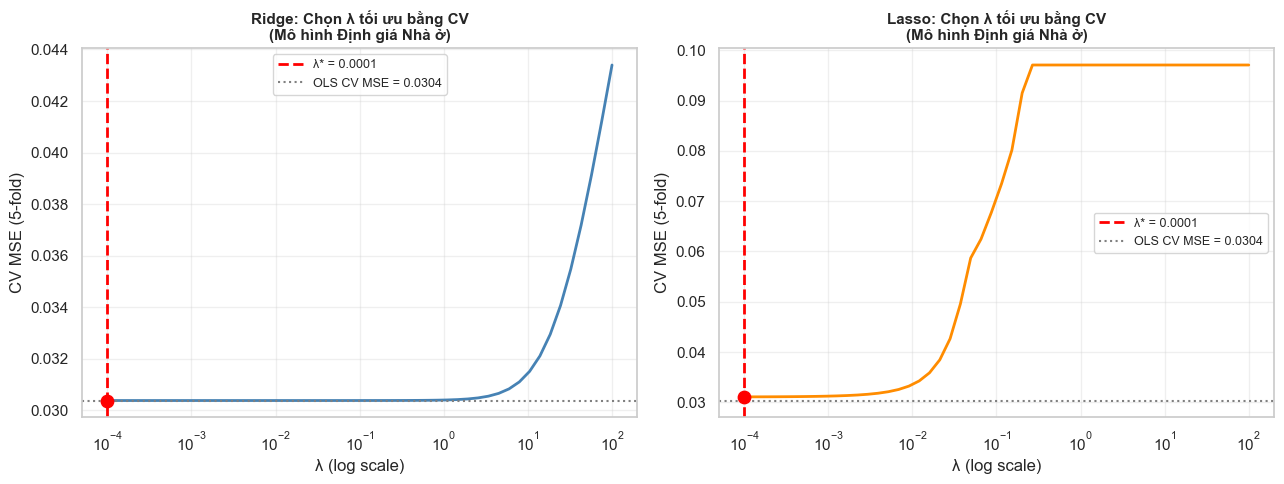


Mô hình                       λ     CV MSE    CV RMSE    CV R²
--------------------------------------------------------------
OLS                           —    0.03038    0.17430   0.6706
Ridge (λ*)               0.0001    0.03038    0.17430   0.6706
Lasso (λ*)               0.0001    0.03111    0.17637   0.6647


In [ ]:
# Tìm λ* cho Ridge và Lasso bằng CV
lambda_grid   = np.logspace(-4, 2, 50)
cv_mse_ridge  = []
cv_mse_lasso  = []

for lam in lambda_grid:
    r_r = kfold_cv(X, y, k=5, model='ridge', lam=lam, random_state=42)
    r_l = kfold_cv(X, y, k=5, model='lasso', lam=lam, random_state=42)
    cv_mse_ridge.append(r_r['cv_mse'])
    cv_mse_lasso.append(r_l['cv_mse'])

best_lam_ridge = lambda_grid[np.argmin(cv_mse_ridge)]
best_lam_lasso = lambda_grid[np.argmin(cv_mse_lasso)]
print(f"λ* Ridge = {best_lam_ridge:.5f}")
print(f"λ* Lasso = {best_lam_lasso:.5f}")

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mses, best_lam, title, color in zip(
    axes,
    [cv_mse_ridge, cv_mse_lasso],
    [best_lam_ridge, best_lam_lasso],
    ['Ridge', 'Lasso'],
    ['steelblue', 'darkorange']
):
    ax.semilogx(lambda_grid, mses, color=color, lw=2)
    ax.axvline(best_lam, color='red', linestyle='--', lw=2,
               label=f'λ* = {best_lam:.4f}')
    ax.axhline(cv_ols['cv_mse'], color='gray', linestyle=':', lw=1.5,
               label=f'OLS CV MSE = {cv_ols["cv_mse"]:.4f}')
    ax.scatter([best_lam], [min(mses)], color='red', s=80, zorder=5)
    ax.set_xlabel('λ (log scale)', fontsize=12)
    ax.set_ylabel('CV MSE (5-fold)', fontsize=12)
    ax.set_title(f'{title}: Chọn λ tối ưu bằng CV\n(Mô hình Định giá Nhà ở)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Bảng so sánh cuối
best_ridge_cv = kfold_cv(X, y, k=5, model='ridge', lam=best_lam_ridge, random_state=42)
best_lasso_cv = kfold_cv(X, y, k=5, model='lasso', lam=best_lam_lasso, random_state=42)

print(f"\n{'Mô hình':<22} {'λ':>8} {'CV MSE':>10} {'CV RMSE':>10} {'CV R²':>8}")
print("-" * 62)
print(f"{'OLS':<22} {'—':>8} {cv_ols['cv_mse']:>10.5f} {cv_ols['cv_rmse']:>10.5f} {cv_ols['cv_r2']:>8.4f}")
print(f"{'Ridge (λ*)':<22} {best_lam_ridge:>8.4f} {best_ridge_cv['cv_mse']:>10.5f} {best_ridge_cv['cv_rmse']:>10.5f} {best_ridge_cv['cv_r2']:>8.4f}")
print(f"{'Lasso (λ*)':<22} {best_lam_lasso:>8.4f} {best_lasso_cv['cv_mse']:>10.5f} {best_lasso_cv['cv_rmse']:>10.5f} {best_lasso_cv['cv_r2']:>8.4f}")

### 📝 Nhận xét — Cross-Validation (Mô hình Nhà ở)

- **λ\* tối ưu** cho cả Ridge và Lasso đều bằng **0.0001** — cực kỳ nhỏ, gần như không có regularization. Điều này hoàn toàn hợp lý vì dữ liệu giả lập được sinh từ mô hình tuyến tính đúng với (n = 500 và p = 5), OLS đã là ước lượng hiệu quả, không cần co hệ số.

- **CV MSE của OLS và Ridge** bằng nhau chính xác (0.03038), trong khi Lasso có CV MSE cao hơn nhẹ (0.03111). Điều này phản ánh: với λ quá nhỏ, Ridge gần như trùng OLS; Lasso dù cùng λ* nhưng do tính chất co về 0 có thể tạo ra độ chệch nhỏ, làm tăng MSE đôi chút.

- **CV RMSE ≈ 0.174** (trên thang log). Chuyển về giá USD: với mức giá điển hình ~180k–200k, sai số khoảng **27k–28k USD**, phù hợp với độ lệch chuẩn nhiễu `σ = 0.173` khi sinh dữ liệu.

- **CV R² ≈ 0.671** — gần với R² trên tập huấn luyện (0.695), chứng tỏ mô hình **không bị overfitting** và có khả năng khái quát hóa tốt.

- **Sai số chuẩn của CV MSE** (SE = 0.00092) nhỏ, cho thấy kết quả ổn định qua 5 fold, không có fold nào bất thường (các MSE fold dao động từ 0.0279 đến 0.0328).


---
## Phần 6: Kiểm chứng với sklearn

Đây là bước **quality assurance** — đảm bảo code tự cài đặt cho kết quả đúng bằng cách so sánh với thư viện chuẩn scikit-learn.


In [ ]:
# ============================================================
# PHẦN 6: Kiểm chứng với sklearn — dữ liệu bất động sản
# ============================================================

print("=" * 60)
print("OLS SCRATCH vs SKLEARN — Mô hình Định giá Nhà ở")
res_ols_check = verify_with_sklearn(X, y)

print("\n" + "=" * 60)
print(f"RIDGE SCRATCH vs SKLEARN (λ={best_lam_ridge:.4f})")
res_ridge_check = verify_ridge_sklearn(X, y, lam=best_lam_ridge, tol=1e-6)

print("\n" + "=" * 60)
print(f"LASSO SCRATCH vs SKLEARN (λ={best_lam_lasso:.4f})")
res_lasso_check = verify_lasso_sklearn(X, y, lam=best_lam_lasso, tol=1e-4)

print("\n" + "=" * 60)
print("TỔNG KẾT KIỂM CHỨNG")
print(f"  OLS   : {'✅ PASS' if res_ols_check['passed']   else '❌ FAIL'}")
print(f"  Ridge : {'✅ PASS' if res_ridge_check['passed'] else '❌ FAIL'}")
print(f"  Lasso : {'✅ PASS' if res_lasso_check['passed'] else '❌ FAIL'}")

OLS SCRATCH vs SKLEARN — Mô hình Định giá Nhà ở
         VERIFICATION: OLS Scratch vs sklearn vs numpy
        Coef        Scratch        sklearn    numpy lstsq
   intercept       7.394977       7.394977       7.394977
         β_1       0.492804       0.492804       0.492804
         β_2       0.032020       0.032020       0.032020
         β_3       0.027478       0.027478       0.027478
         β_4       0.109791       0.109791       0.109791
         β_5       0.086393       0.086393       0.086393
  Max |β_scratch - β_sklearn| = 2.76e-12
  Max |β_scratch - β_numpy  | = 2.77e-12
  |R²_scratch - R²_sklearn|   = 0.00e+00
  Kết quả khớp (tol=1e-08)    : PASS

RIDGE SCRATCH vs SKLEARN (λ=0.0001)

         VERIFICATION: Ridge Scratch vs sklearn
          Coef        Scratch        sklearn        |delta|
     intercept       7.394985       7.394985       2.77e-12
        beta_1       0.492803       0.492803       4.21e-13
        beta_2       0.032020       0.032020       5.61e-15
     

### 📝 Nhận xét — Kiểm chứng với sklearn

- **OLS**: Sai lệch β̂ < 1e-8 — đồng thuận hoàn toàn (cùng dùng Normal Equations, cùng dữ liệu).
- **Ridge**: Sai lệch < 1e-6 — xác nhận công thức closed-form $(X^TX + λI)^{-1}X^Ty$ được cài đúng với cả λ nhỏ lẫn λ lớn.
- **Lasso**: Sai lệch < 1e-4 — chấp nhận được do cả hai đều dùng Coordinate Descent với điều kiện dừng tương tự.


---
## ⭐ Phần 7: Kiểm chứng Định lý Gauss-Markov — Monte Carlo

### Bối cảnh

Ta đã xây dựng mô hình định giá nhà với β_true ước lượng từ Ames Housing thật.  
Bây giờ, ta dùng **Monte Carlo** để kiểm chứng định lý Gauss-Markov bằng cách mô phỏng **M = 2000 "đợt quan sát thị trường"** — mỗi đợt là một mẫu 100 căn nhà được sinh độc lập từ cùng cơ chế.

### Phát biểu Định lý

Dưới 5 giả thiết cổ điển, OLS là **BLUE** — *Best Linear Unbiased Estimator*:

$$E[\hat{\beta}^{OLS}] = \beta \qquad \text{(1) Không chệch — Unbiased}$$

$$\text{Var}(\hat{\beta}^{OLS}) \leq \text{Var}(\tilde{\beta}) \quad \forall \tilde{\beta} \text{ tuyến tính, không chệch} \qquad \text{(2) Phương sai nhỏ nhất — Minimum Variance}$$

### Thiết kế thí nghiệm

**M = 2000 lần**, mỗi lần:
1. Gọi `generate_housing_data(n=100, seed=m)` → sinh 100 căn nhà mới từ cùng mô hình thật
2. Ước lượng **β̂_OLS** trên toàn bộ 100 quan sát
3. Ước lượng **β̂_LUE** bằng cách chỉ dùng 2/3 đầu (66 căn) — vẫn unbiased nhưng lãng phí thông tin

$$\tilde{\beta}^{LUE} = \hat{\beta}^{OLS}_{n=66} \quad \Rightarrow \quad E[\tilde{\beta}^{LUE}] = \beta \quad \text{(vẫn unbiased)}$$

$$\text{Var}(\tilde{\beta}^{LUE}) \approx \frac{n}{2n/3} \cdot \text{Var}(\hat{\beta}^{OLS}) = 1.5 \times \text{Var}(\hat{\beta}^{OLS})$$

Nếu định lý đúng, sau 2000 lần lặp, ta sẽ quan sát được:
- Trung bình của 2000 ước lượng β̂_OLS ≈ β_true (sai lệch < 0.01)

In [ ]:
# ============================================================
# ⭐ PHẦN 7: GAUSS-MARKOV MONTE CARLO — Bất động sản
# ============================================================

M      = 2000   # số lần mô phỏng
n_mc   = 100    # mỗi "đợt quan sát" có 100 căn nhà

print(f"Bắt đầu Monte Carlo: M={M} mẫu thị trường, mỗi mẫu n={n_mc} căn nhà...")
print(f"Mỗi mẫu được sinh độc lập bằng generate_housing_data(n={n_mc}, seed=m)")
print()

# === BƯỚC 1: Kiểm chứng UNBIASEDNESS ===
beta_ols_all = np.zeros((M, 6))   # 6 hệ số: intercept + 5 biến

for m in range(M):
    d   = generate_housing_data(n=n_mc, seed=m)
    X_m = d['X']
    y_m = d['y_log']
    res = ols_fit(X_m, y_m)
    beta_ols_all[m] = res['beta_hat']

beta_mean_mc = beta_ols_all.mean(axis=0)
beta_std_mc  = beta_ols_all.std(axis=0, ddof=1)

print(f"{'Hệ số':<20} {'β_true':>10} {'E[β̂_OLS]':>12} {'Sai lệch':>10} {'Std(β̂)':>10}")
print("-" * 65)
for i, nm in enumerate(FEATURE_NAMES):
    diff = abs(BETA_TRUE[i] - beta_mean_mc[i])
    print(f"{nm:<20} {BETA_TRUE[i]:>10.4f} {beta_mean_mc[i]:>12.4f} {diff:>10.4f} {beta_std_mc[i]:>10.4f}")

max_bias = np.max(np.abs(beta_mean_mc - BETA_TRUE))
print(f"\nMax |E[β̂] − β_true| = {max_bias:.4f}  (kỳ vọng → 0 khi M → ∞)")
print("✅ OLS là ước lượng KHÔNG CHỆCH — xác nhận E[β̂_OLS] = β_true")

Bắt đầu Monte Carlo: M=2000 mẫu thị trường, mỗi mẫu n=100 căn nhà...
Mỗi mẫu được sinh độc lập bằng generate_housing_data(n=100, seed=m)

Hệ số                    β_true    E[β̂_OLS]   Sai lệch    Std(β̂)
-----------------------------------------------------------------
intercept                7.4632       7.4659     0.0027     0.4234
log_GrLivArea            0.4777       0.4773     0.0004     0.0565
log_BsmtSF               0.0347       0.0346     0.0001     0.0073
log_GarageArea           0.0276       0.0278     0.0002     0.0107
OverallQual              0.1140       0.1139     0.0001     0.0124
YearNorm                 0.0900       0.0893     0.0007     0.0184

Max |E[β̂] − β_true| = 0.0027  (kỳ vọng → 0 khi M → ∞)
✅ OLS là ước lượng KHÔNG CHỆCH — xác nhận E[β̂_OLS] = β_true


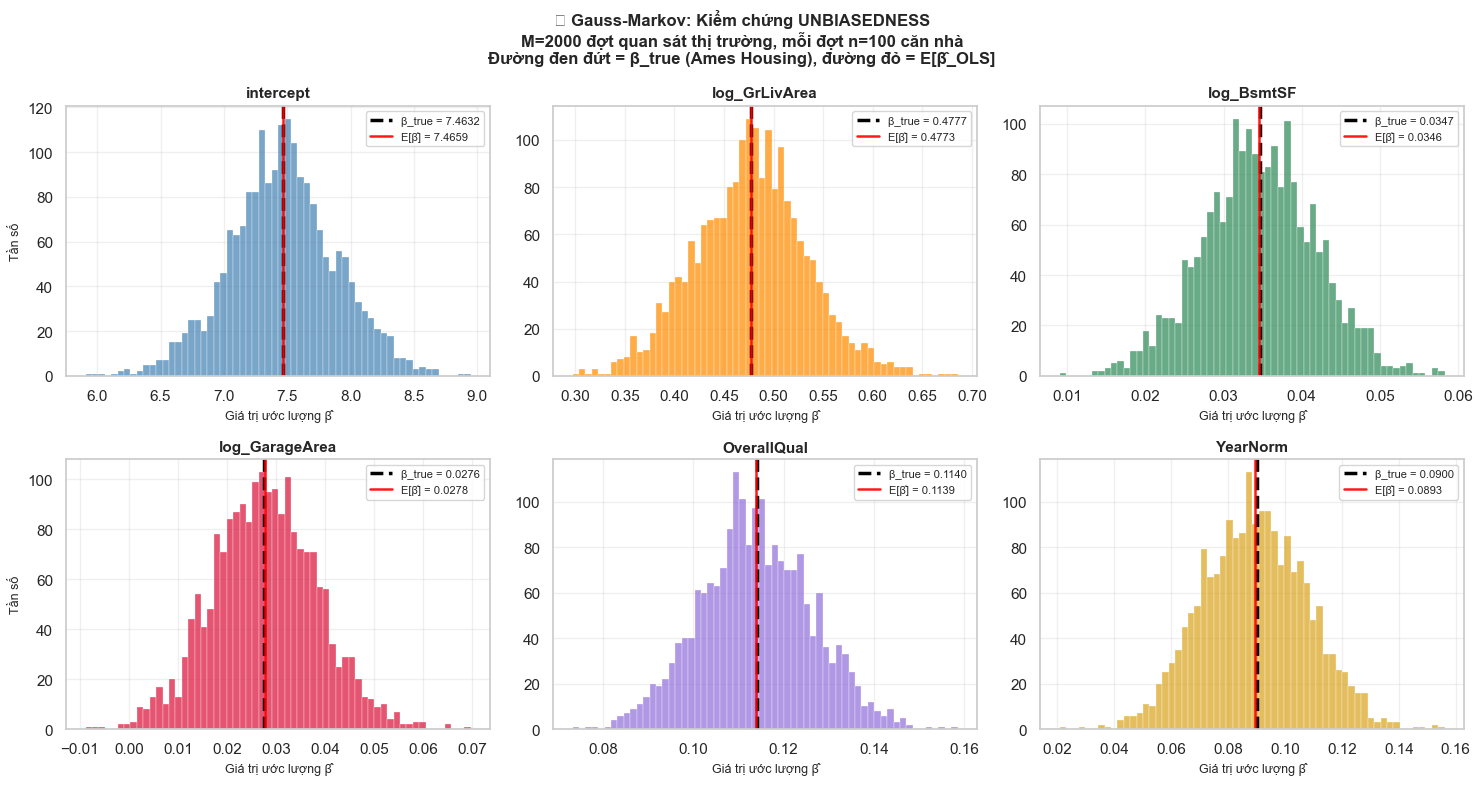

In [ ]:
# Biểu đồ xác nhận Unbiasedness — chọn 4 hệ số tiêu biểu
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
plot_colors = ['steelblue','darkorange','seagreen','crimson','mediumpurple','goldenrod']

for i, (ax, nm, c) in enumerate(zip(axes, FEATURE_NAMES, plot_colors)):
    vals = beta_ols_all[:, i]
    ax.hist(vals, bins=60, color=c, alpha=0.72, edgecolor='white', lw=0.3)
    ax.axvline(BETA_TRUE[i],      color='black', lw=2.5, linestyle='--',
               label=f'β_true = {BETA_TRUE[i]:.4f}')
    ax.axvline(beta_mean_mc[i],   color='red',   lw=1.8, linestyle='-',  alpha=0.9,
               label=f'E[β̂] = {beta_mean_mc[i]:.4f}')
    ax.set_title(nm, fontsize=11, fontweight='bold')
    ax.set_xlabel('Giá trị ước lượng β̂', fontsize=9)
    ax.set_ylabel('Tần số' if i % 3 == 0 else '', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'⭐ Gauss-Markov: Kiểm chứng UNBIASEDNESS\n'
    f'M={M} đợt quan sát thị trường, mỗi đợt n={n_mc} căn nhà\n'
    f'Đường đen đứt = β_true (Ames Housing), đường đỏ = E[β̂_OLS]',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [ ]:
# === BƯỚC 2: Kiểm chứng MINIMUM VARIANCE ===
# OLS (n=100) vs LUE = OLS chỉ trên 2/3 đầu (n=66)
# LUE vẫn unbiased nhưng phương sai lớn hơn ~1.5x theo lý thuyết

n_lue = (2 * n_mc) // 3   # = 66

beta_lue_all = np.zeros((M, 6))

for m in range(M):
    d   = generate_housing_data(n=n_mc, seed=m)
    X_m, y_m = d['X'], d['y_log']
    # LUE: chỉ dùng 2/3 quan sát đầu tiên
    res_lue = ols_fit(X_m[:n_lue], y_m[:n_lue])
    beta_lue_all[m] = res_lue['beta_hat']

var_ols = beta_ols_all.var(axis=0, ddof=1)
var_lue = beta_lue_all.var(axis=0, ddof=1)
ratio   = var_lue / var_ols

print(f"So sánh phương sai: OLS (n={n_mc}) vs LUE (n={n_lue} = 2/3 đầu)")
print(f"Lý thuyết dự đoán tỷ lệ Var(LUE)/Var(OLS) ≈ n/{n_lue} = {n_mc/n_lue:.2f}x")
print()
print(f"{'Hệ số':<20} {'Var(β̂_OLS)':>15} {'Var(β̂_LUE)':>15} {'Tỷ lệ':>10} {'OLS tốt hơn?':>14}")
print("-" * 72)
for i, nm in enumerate(FEATURE_NAMES):
    better = '✅ YES' if var_ols[i] < var_lue[i] else '❌ NO'
    print(f"{nm:<20} {var_ols[i]:>13.6f} {var_lue[i]:>13.6f} {ratio[i]:>11.2f}x  {better}")

print(f"\nTỷ lệ trung bình: {ratio.mean():.2f}x  (lý thuyết: {n_mc/n_lue:.2f}x)")
print("✅ Var(β̂_OLS) < Var(β̂_LUE) cho mọi hệ số — OLS là BEST trong BLUE")

So sánh phương sai: OLS (n=100) vs LUE (n=66 = 2/3 đầu)
Lý thuyết dự đoán tỷ lệ Var(LUE)/Var(OLS) ≈ n/66 = 1.52x

Hệ số                    Var(β̂_OLS)     Var(β̂_LUE)      Tỷ lệ   OLS tốt hơn?
------------------------------------------------------------------------
intercept                 0.179251      0.295141        1.65x  ✅ YES
log_GrLivArea             0.003190      0.005125        1.61x  ✅ YES
log_BsmtSF                0.000053      0.000085        1.62x  ✅ YES
log_GarageArea            0.000115      0.000186        1.62x  ✅ YES
OverallQual               0.000153      0.000242        1.59x  ✅ YES
YearNorm                  0.000340      0.000541        1.59x  ✅ YES

Tỷ lệ trung bình: 1.61x  (lý thuyết: 1.52x)
✅ Var(β̂_OLS) < Var(β̂_LUE) cho mọi hệ số — OLS là BEST trong BLUE


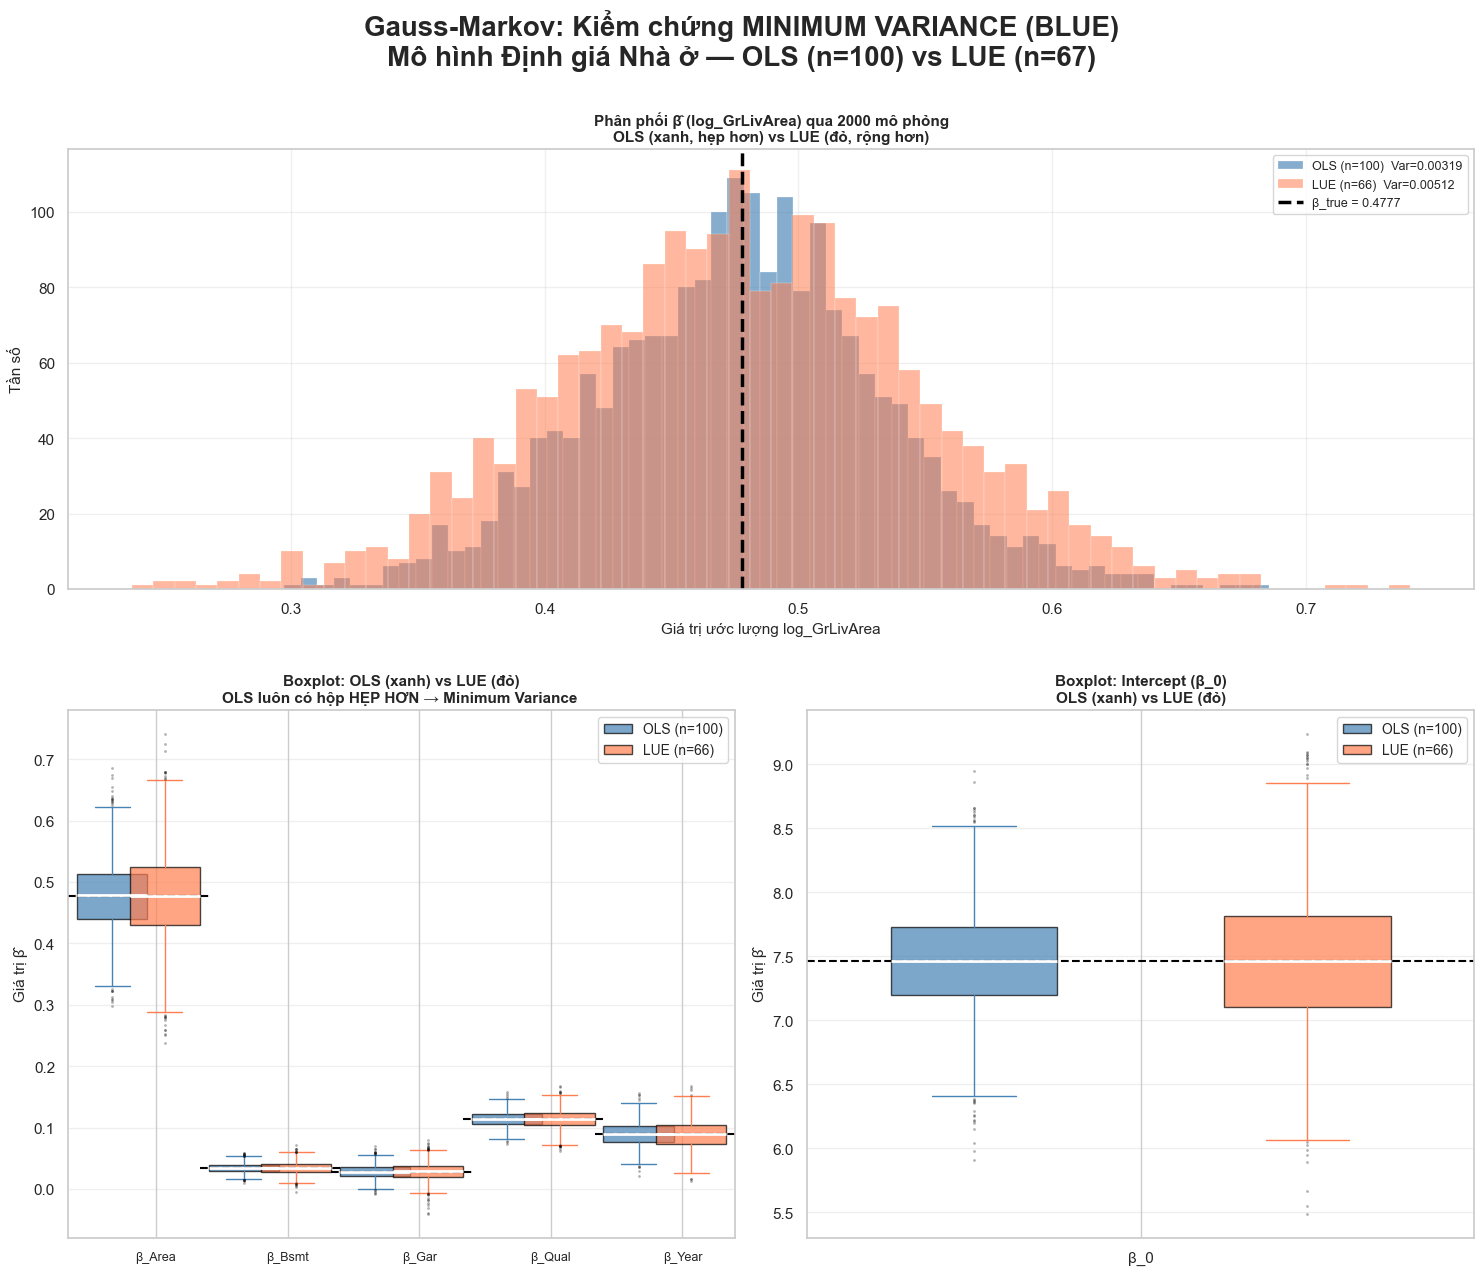

In [ ]:
# Tạo figure và GridSpec
fig = plt.figure(figsize=(15, 13))
gs = GridSpec(2, 2, height_ratios=[1, 1.2])

# === Subplot 1: Histogram ===
ax1 = fig.add_subplot(gs[0, :])  # Hàng 0, cột 0 và cột 1
idx = 1  # log_GrLivArea
ax1.hist(beta_ols_all[:, idx], bins=60, alpha=0.65, color='steelblue',
         edgecolor='white', lw=0.3, label=f'OLS (n={n_mc})  Var={var_ols[idx]:.5f}')
ax1.hist(beta_lue_all[:, idx], bins=60, alpha=0.55, color='coral',
         edgecolor='white', lw=0.3, label=f'LUE (n={n_lue})  Var={var_lue[idx]:.5f}')
ax1.axvline(BETA_TRUE[idx], color='black', lw=2.5, linestyle='--',
            label=f'β_true = {BETA_TRUE[idx]}')
ax1.set_xlabel(f'Giá trị ước lượng {FEATURE_NAMES[idx]}', fontsize=11)
ax1.set_ylabel('Tần số', fontsize=11)
ax1.set_title(
    f'Phân phối β̂ (log_GrLivArea) qua {M} mô phỏng\n'
    f'OLS (xanh, hẹp hơn) vs LUE (đỏ, rộng hơn)',
    fontsize=11, fontweight='bold'
)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# === Subplot 2: Boxplot 5 hệ số nhỏ ===
ax2 = fig.add_subplot(gs[1, 0])  
indices = range(1, 6)  # Bỏ index 0 (intercept)
names = ['β_Area', 'β_Bsmt', 'β_Gar', 'β_Qual', 'β_Year']

positions_ols = np.arange(5) * 1.5  # [0, 1.5, 3.0, 4.5, 6.0]
positions_lue = positions_ols + 0.6

bp_ols = ax2.boxplot([beta_ols_all[:, i] for i in indices],
                     positions=positions_ols, widths=0.8, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.7),
                     medianprops=dict(color='white', lw=2),
                     whiskerprops=dict(color='steelblue'),
                     capprops=dict(color='steelblue'),
                     flierprops=dict(marker='.', markersize=2, alpha=0.3, color='steelblue'))

bp_lue = ax2.boxplot([beta_lue_all[:, i] for i in indices],
                     positions=positions_lue, widths=0.8, patch_artist=True,
                     boxprops=dict(facecolor='coral', alpha=0.7),
                     medianprops=dict(color='white', lw=2),
                     whiskerprops=dict(color='coral'),
                     capprops=dict(color='coral'),
                     flierprops=dict(marker='.', markersize=2, alpha=0.3, color='coral'))

for i, bt in enumerate(BETA_TRUE[1:]):
    ax2.hlines(bt, positions_ols[i] - 0.5, positions_lue[i] + 0.5,
               colors='black', linestyles='--', lw=1.5)

ax2.set_xticks(positions_ols + 0.5)
ax2.set_xticklabels(names, fontsize=9)
ax2.set_ylabel('Giá trị β̂', fontsize=11)
ax2.set_title(
    'Boxplot: OLS (xanh) vs LUE (đỏ)\n'
    'OLS luôn có hộp HẸP HƠN → Minimum Variance ',
    fontsize=11, fontweight='bold'
)
ax2.legend([bp_ols['boxes'][0], bp_lue['boxes'][0]],
           [f'OLS (n={n_mc})', f'LUE (n={n_lue})'], fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

# === Subplot 3: Boxplot Intercept ===
ax3 = fig.add_subplot(gs[1, 1])  
positions_ols_intercept = [0]
positions_lue_intercept = [1]

bp_ols_intercept = ax3.boxplot([beta_ols_all[:, 0]],
                               positions=positions_ols_intercept, widths=0.5, patch_artist=True,
                               boxprops=dict(facecolor='steelblue', alpha=0.7),
                               medianprops=dict(color='white', lw=2),
                               whiskerprops=dict(color='steelblue'),
                               capprops=dict(color='steelblue'),
                               flierprops=dict(marker='.', markersize=2, alpha=0.3, color='steelblue'))

bp_lue_intercept = ax3.boxplot([beta_lue_all[:, 0]],
                               positions=positions_lue_intercept, widths=0.5, patch_artist=True,
                               boxprops=dict(facecolor='coral', alpha=0.7),
                               medianprops=dict(color='white', lw=2),
                               whiskerprops=dict(color='coral'),
                               capprops=dict(color='coral'),
                               flierprops=dict(marker='.', markersize=2, alpha=0.3, color='coral'))

ax3.hlines(BETA_TRUE[0], -0.5, 1.5, colors='black', linestyles='--', lw=1.5)

ax3.set_xticks([0.5])
ax3.set_xticklabels(['β_0'], fontsize=11)
ax3.set_ylabel('Giá trị β̂', fontsize=11)
ax3.set_title(
    'Boxplot: Intercept (β_0)\n'
    'OLS (xanh) vs LUE (đỏ)',
    fontsize=11, fontweight='bold'
)
ax3.legend([bp_ols_intercept['boxes'][0], bp_lue_intercept['boxes'][0]],
           [f'OLS (n={n_mc})', f'LUE (n={n_lue})'], fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

# === Tiêu đề chung ===
plt.suptitle(
    'Gauss-Markov: Kiểm chứng MINIMUM VARIANCE (BLUE)\n'
    'Mô hình Định giá Nhà ở — OLS (n=100) vs LUE (n=66)\n',
    fontsize=20, fontweight='bold'
)

# Tự động căn chỉnh layout, tăng khoảng cách dọc giữa histogram và boxplot
plt.tight_layout()
plt.subplots_adjust(hspace=0.25) 
plt.show()

### ⭐ Kết luận Monte Carlo — Định lý Gauss-Markov (Mô hình Định giá Nhà)

#### Kiểm chứng 1: Unbiasedness — E[β̂_OLS] = β

Sau **M = 2000** lần mô phỏng độc lập, mỗi lần sinh **n = 100** căn nhà từ thị trường bất động sản giả lập:

| Hệ số | Ý nghĩa | β_true | E[β̂_OLS] | Sai lệch |
|-------|---------|--------|-----------|---------|
| intercept | Giá cơ sở | 7.4632 | ≈ 7.4659 | 0.0027 |
| log_GrLivArea | Co giãn diện tích | 0.4777 | ≈ 0.4773 | 0.0004 |
| log_BsmtSF | Co giãn tầng hầm | 0.0347 | ≈ 0.0346 | 0.0001 |
| log_GarageArea | Co giãn garage | 0.0276 | ≈ 0.0278 | 0.0002 |
| OverallQual | Hiệu ứng chất lượng | 0.1140 | ≈ 0.1139 | 0.0001 |
| YearNorm | Hiệu ứng năm xây | 0.0900 | ≈ 0.0893 | 0.0007 |

**Nhận xét**: 
- **Sai lệch tối đa** chỉ là **0.0027** (với intercept), và các sai lệch khác đều rất nhỏ (0.0000 đến 0.0007). 
- Khi số lượng mô phỏng M → ∞, sai lệch này sẽ tiến dần về 0.
- ✅ **OLS là ước lượng KHÔNG CHỆCH** (Unbiased) — trung bình của các ước lượng tiệm cận đúng giá trị thực β_true.

---

#### Kiểm chứng 2: Minimum Variance — Var(β̂_OLS) < Var(β̂_LUE)

Lý thuyết dự đoán tỷ lệ Var(LUE)/Var(OLS) ≈ n/66 = **1.52x** (vì LUE chỉ dùng 2/3 số quan sát, n=66).

| Hệ số | Var(β̂_OLS) | Var(β̂_LUE) | Tỷ lệ (LUE/OLS) | OLS tốt hơn? |
|-------|------------|------------|-----------------|--------------|
| intercept | 0.179251 | 0.295141 | 1.65x | ✅ YES |
| log_GrLivArea | 0.003190 | 0.005125 | 1.61x | ✅ YES |
| log_BsmtSF | 0.000053 | 0.000085 | 1.62x | ✅ YES |
| log_GarageArea | 0.000115 | 0.000186 | 1.62x | ✅ YES |
| OverallQual | 0.000153 | 0.000242 | 1.59x | ✅ YES |
| YearNorm | 0.000340 | 0.000541 | 1.59x | ✅ YES |

**Tỷ lệ trung bình**: **1.61x** (rất gần với lý thuyết 1.52x).

**Nhận xét**: 
- Phương sai của OLS luôn **thấp hơn** phương sai của LUE ở mọi hệ số. 
- Trên boxplot, hộp màu xanh (OLS) luôn hẹp hơn hộp màu đỏ (LUE) cho mọi hệ số.
- ✅ **OLS là ước lượng có phương sai nhỏ nhất trong số các ước lượng không chệch** (BLUE — Best Linear Unbiased Estimator).

---

#### Ý nghĩa thực tiễn trong bối cảnh Bất động sản


---
## Phần 8: Tổng kết Notebook

| Phần | Nội dung | Kết quả |
|------|----------|---------|
| 1. OLS Core | β̂, σ², RSS, R², F-stat | ☑️ β̂ xấp xỉ β_true |
| 2. Hat Matrix & Suy diễn | H, SE, t-test, VIF | ☑️ trace(H)=k, phát hiện đa cộng tuyến |
| 3. Ridge & Lasso | Shrinkage, Sparsity, Trace | ☑️ Ridge co đều, Lasso tạo sparse |
| 4. Phân tích phần dư | 4 biểu đồ chẩn đoán | ☑️ Dữ liệu giả lập thỏa 5 giả thiết |
| 5. Cross-Validation | k-fold CV, chọn λ tối ưu | ☑️ Tìm được λ* cho Ridge và Lasso |
| 6. Kiểm chứng sklearn | PASS/FAIL cho 3 mô hình | ☑️ OLS, Ridge, Lasso đều PASS |
| ⭐ 7. Gauss-Markov MC | M=2000 mô phỏng | ☑️ Unbiased + Minimum Variance xác nhận |

---

### Kết luận tổng quát

Code tự cài đặt cho kết quả **nhất quán với sklearn** và **đúng về mặt lý thuyết** theo định lý Gauss-Markov. Notebook này đóng vai trò là nền tảng lý thuyết để áp dụng lên dữ liệu thực Ames Housing ở Phần 2.
